In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, OneHotEncoder, TargetEncoder, RobustScaler
from sklearn.metrics import silhouette_score, make_scorer
import joblib
import seaborn as sns
from sklearn.model_selection import GridSearchCV, KFold
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import pygeohash as pgh
import geopy as gpy
import numpy as np
import warnings
from sklearn.decomposition import PCA
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px
from sklearn.mixture import GaussianMixture
import os

%load_ext autoreload
%autoreload 2

In [2]:
filename = 'research_centers.csv'
columns_to_drop = ['researchCenterId', 'researchCenterName']
geographical_cols = ['latitude', 'longitude']
count_data_cols = ['internalFacilitiesCount', 'hospitals_10km', 'pharmacies_10km']
ratio_cols = ['facilityDiversity_10km', 'facilityDensity_10km']
categorical_cols = ['city']
colors = plt.cm.tab20.colors
geohash_precision = 4
geolocater = gpy.geocoders.Nominatim(user_agent="research_grid_geocoder")
os.makedirs('models', exist_ok=True)

# Load

In [3]:
raw_df = pd.read_csv(filename)
raw_df.head()

,researchCenterId,researchCenterName,city,latitude,longitude,internalFacilitiesCount,hospitals_10km,pharmacies_10km,facilityDiversity_10km,facilityDensity_10km
0,RC-014,Research Center 14,City 4,50.7713,-1.9260,3,1,0,0.374488,0.177506
1,RC-040,Research Center 40,City 2,50.5088,-1.3637,2,1,1,0.391903,0.108965
2,RC-031,Research Center 31,City 4,50.2202,-1.2889,3,0,1,0.293552,0.076155
3,RC-046,Research Center 46,City 5,50.9362,-1.3040,11,4,4,0.884502,0.697016
4,RC-018,Research Center 18,City 2,50.0254,-1.8921,10,4,5,0.842611,0.568983


In [4]:
raw_df.info(), raw_df.duplicated().sum()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   researchCenterId         50 non-null     str    
 1   researchCenterName       50 non-null     str    
 2   city                     50 non-null     str    
 3   latitude                 50 non-null     float64
 4   longitude                50 non-null     float64
 5   internalFacilitiesCount  50 non-null     int64  
 6   hospitals_10km           50 non-null     int64  
 7   pharmacies_10km          50 non-null     int64  
 8   facilityDiversity_10km   50 non-null     float64
 9   facilityDensity_10km     50 non-null     float64
dtypes: float64(4), int64(3), str(3)
memory usage: 4.0 KB


(None, np.int64(0))

# Explore

In [5]:
raw_df['researchCenterName'].nunique(), raw_df['city'].nunique(), raw_df.columns

(50,
 5,
 Index(['researchCenterId', 'researchCenterName', 'city', 'latitude',
        'longitude', 'internalFacilitiesCount', 'hospitals_10km',
        'pharmacies_10km', 'facilityDiversity_10km', 'facilityDensity_10km'],
       dtype='str'))

In [6]:
df = raw_df.set_index('researchCenterId')
for geohash_num in range(2, 10):
    df[f'geohash_{geohash_num}'] = df.apply(lambda x: pgh.encode(x['latitude'], x['longitude'], precision = geohash_num), axis=1)
df['external_score'] = df['hospitals_10km'] + df['pharmacies_10km']
df['internal_external_ratio'] = df['internalFacilitiesCount'] / (df['hospitals_10km'] + df['pharmacies_10km'] + 1) 
df['healthcare_deficit'] = (df['hospitals_10km'] + df['pharmacies_10km']) == 0
df['lat_rad'] = np.radians(df['latitude'])
df['lon_rad'] = np.radians(df['longitude'])
df['cart_x'] = np.cos(df['lat_rad']) * np.cos(df['lon_rad'])
df['cart_y'] = np.cos(df['lat_rad']) * np.sin(df['lon_rad'])
df['cart_z'] = np.sin(df['lat_rad'])
df.drop(columns =['lat_rad', 'lon_rad'], inplace=True)
# coordinates_series = df['latitude'].astype(str).str.cat(df['longitude'].astype(str), sep=',') 
df.head()

,researchCenterName,city,latitude,longitude,internalFacilitiesCount,hospitals_10km,pharmacies_10km,facilityDiversity_10km,facilityDensity_10km,geohash_2,...,geohash_6,geohash_7,geohash_8,geohash_9,external_score,internal_external_ratio,healthcare_deficit,cart_x,cart_y,cart_z
researchCenterId,,,,,,,,,,,,,,,,,,,,,
RC-014,Research Center 14,City 4,50.7713,-1.9260,3,1,0,0.374488,0.177506,gc,...,gcn8u4,gcn8u4t,gcn8u4ts,gcn8u4ts2,1,1.500000,False,0.632060,-0.021255,0.774628
RC-040,Research Center 40,City 2,50.5088,-1.3637,2,1,1,0.391903,0.108965,gb,...,gbzp2f,gbzp2fy,gbzp2fyg,gbzp2fygp,2,0.666667,False,0.635780,-0.015135,0.771722
RC-031,Research Center 31,City 4,50.2202,-1.2889,3,0,1,0.293552,0.076155,gb,...,gbzjdw,gbzjdwm,gbzjdwm3,gbzjdwm3y,1,1.500000,False,0.639677,-0.014392,0.768509
RC-046,Research Center 46,City 5,50.9362,-1.3040,11,4,4,0.884502,0.697016,gc,...,gcp1f2,gcp1f2d,gcp1f2dk,gcp1f2dky,8,1.222222,False,0.630022,-0.014341,0.776445
RC-018,Research Center 18,City 2,50.0254,-1.8921,10,4,5,0.842611,0.568983,gb,...,gbyssf,gbyssfy,gbyssfy5,gbyssfy5n,9,1.000000,False,0.642098,-0.021212,0.766329


In [7]:
df[['city','geohash_2', 'geohash_3', 'geohash_4']].nunique()

city          5
geohash_2     2
geohash_3     4
geohash_4    20
dtype: int64

In [8]:
df.groupby('city').agg(**{
    'precision 2 unique': ('geohash_2', 'nunique'),
    'precision 2 names': ('geohash_2', 'unique'),
    'precision 3 unique': ('geohash_3', 'nunique'),
    'precision 3 names': ('geohash_3', 'unique'),
    'precision 4 unique': ('geohash_4', 'nunique'),
    'precision 4 names': ('geohash_4', 'unique')
})

,precision 2 unique,precision 2 names,precision 3 unique,precision 3 names,precision 4 unique,precision 4 names
city,,,,,,
City 1,2,"[gb, gc]",4,"[gby, gcn, gbz, gcp]",9,"[gbyy, gbys, gcnb, gcnc, gcnd, gbzn, gcp1, gby..."
City 2,2,"[gb, gc]",4,"[gbz, gby, gcn, gcp]",6,"[gbzp, gbys, gcn8, gbyw, gcnc, gcp1]"
City 3,2,"[gc, gb]",4,"[gcn, gby, gbz, gcp]",10,"[gcnc, gbyu, gbyy, gbyw, gbzq, gbyz, gbyv, gcp..."
City 4,2,"[gc, gb]",4,"[gcn, gbz, gby, gcp]",9,"[gcn8, gbzj, gbyv, gcp4, gcp0, gcnb, gcp1, gcn..."
City 5,2,"[gc, gb]",4,"[gcp, gby, gcn, gbz]",9,"[gcp1, gbyu, gcn9, gcp0, gcnb, gbzp, gbys, gcn..."


### Research Centers - each record is a research center

In [9]:
df[['researchCenterName']].nunique()

researchCenterName    50
dtype: int64

Filtering needs to be done by examinining and looking at the city heat map

### City

In [10]:
df['city'].nunique(), df['city'].unique()

(5,
 <StringArray>
 ['City 4', 'City 2', 'City 5', 'City 3', 'City 1']
 Length: 5, dtype: str)

In [11]:
city_summary_df = df.groupby('city').agg(**{
    'Total Research Centers': ('researchCenterName', 'nunique'),
    'Total Facilities': ('internalFacilitiesCount', 'sum'),
    'Total Hospitals': ('hospitals_10km', 'sum'),
    'Total Pharmacies': ('pharmacies_10km', 'sum')
})
city_summary_df.loc['Total', :]  = city_summary_df.sum()
city_summary_df.loc[:,'Research Distribution'] = round(city_summary_df['Total Research Centers'] / city_summary_df.loc['Total', 'Total Research Centers'] * 100, 2)
city_summary_df.loc[:,'Facility Distribution'] = round(city_summary_df['Total Facilities'] / city_summary_df.loc['Total', 'Total Facilities'] * 100, 2)
city_summary_df.loc[:,'Hospital Distribution'] = round(city_summary_df['Total Hospitals'] / city_summary_df.loc['Total', 'Total Hospitals'] * 100, 2)
city_summary_df.loc[:,'Pharmacy Distribution'] = round(city_summary_df['Total Pharmacies'] / city_summary_df.loc['Total', 'Total Pharmacies'] * 100, 2)

city_summary_df

,Total Research Centers,Total Facilities,Total Hospitals,Total Pharmacies,Research Distribution,Facility Distribution,Hospital Distribution,Pharmacy Distribution
city,,,,,,,,
City 1,11.0,72.0,22.0,34.0,22.0,25.44,23.66,30.36
City 2,6.0,32.0,12.0,16.0,12.0,11.31,12.90,14.29
City 3,14.0,71.0,22.0,27.0,28.0,25.09,23.66,24.11
City 4,10.0,54.0,20.0,16.0,20.0,19.08,21.51,14.29
City 5,9.0,54.0,17.0,19.0,18.0,19.08,18.28,16.96
Total,50.0,283.0,93.0,112.0,100.0,100.00,100.00,100.00


In [12]:
geohash_summary_list = []

for a_geohash in ['geohash_2', 'geohash_3', 'geohash_4']:
    temp_geohash_summary_df = df.groupby(a_geohash).agg(**{
        'Total Research Centers': ('researchCenterName', 'nunique'),
        'Total Facilities': ('internalFacilitiesCount', 'sum'),
        'Total Hospitals': ('hospitals_10km', 'sum'),
        'Total Pharmacies': ('pharmacies_10km', 'sum')
    })
    temp_geohash_summary_df.loc[f'Total {a_geohash}', :]  = temp_geohash_summary_df.sum()
    temp_geohash_summary_df.loc[:,'Research Distribution'] = round(temp_geohash_summary_df['Total Research Centers'] / temp_geohash_summary_df.loc[f'Total {a_geohash}', 'Total Research Centers'] * 100, 2)
    temp_geohash_summary_df.loc[:,'Facility Distribution'] = round(temp_geohash_summary_df['Total Facilities'] / temp_geohash_summary_df.loc[f'Total {a_geohash}', 'Total Facilities'] * 100, 2)
    temp_geohash_summary_df.loc[:,'Hospital Distribution'] = round(temp_geohash_summary_df['Total Hospitals'] / temp_geohash_summary_df.loc[f'Total {a_geohash}', 'Total Hospitals'] * 100, 2)
    temp_geohash_summary_df.loc[:,'Pharmacy Distribution'] = round(temp_geohash_summary_df['Total Pharmacies'] / temp_geohash_summary_df.loc[f'Total {a_geohash}', 'Total Pharmacies'] * 100, 2)

    temp_geohash_summary_df.drop(index=f'Total {a_geohash}', inplace=True)
    temp_geohash_summary_df = pd.concat([temp_geohash_summary_df.rename_axis('city')], axis=0, keys=[a_geohash])

    geohash_summary_list.append(temp_geohash_summary_df)

geohash_summary_df = pd.concat(geohash_summary_list, axis=0)
geohash_summary_df.head()

Total Research Centers  Total Facilities  Total Hospitals  \
          city                                                              
geohash_2 gb                      24.0             124.0             39.0   
          gc                      26.0             159.0             54.0   
geohash_3 gby                     19.0             109.0             36.0   
          gbz                      5.0              15.0              3.0   
          gcn                     17.0             102.0             34.0   

                Total Pharmacies  Research Distribution  \
          city                                            
geohash_2 gb                50.0                   48.0   
          gc                62.0                   52.0   
geohash_3 gby               46.0                   38.0   
          gbz                4.0                   10.0   
          gcn               40.0                   34.0   

                Facility Distribution  Hospital Distribution  \
          city                                                 
geohash_2 gb                    43.82                  41.94   
          gc                    56.18                  58.06   
geohash_3 gby                   38.52                  38.71   
          gbz                    5.30                   3.23   
          gcn                   36.04                  36.56   

                Pharmacy Distribution  
          city                         
geohash_2 gb                    44.64  
          gc                    55.36  
geohash_3 gby                   41.07  
          gbz                    3.57  
          gcn                   35.71

In [13]:
fig = px.scatter(
    df,
    x="latitude",
    y="longitude",
    color="city",
    hover_data=["researchCenterName"]
)

fig.update_layout(title="City Locations by Coordinates")
fig.show()

In [14]:
fig = px.scatter(
    df,
    x="latitude",
    y="longitude",
    color="geohash_2",
    hover_data=["researchCenterName"]
)

fig.update_layout(title="City Locations by Coordinates")
fig.show()

In [15]:
fig = px.scatter(
    df,
    x="latitude",
    y="longitude",
    color="geohash_3",
    hover_data=["researchCenterName"]
)

fig.update_layout(title="City Locations by Coordinates")
fig.show()

In [16]:
geohash_summary_df.loc['geohash_3']

,Total Research Centers,Total Facilities,Total Hospitals,Total Pharmacies,Research Distribution,Facility Distribution,Hospital Distribution,Pharmacy Distribution
city,,,,,,,,
gby,19.0,109.0,36.0,46.0,38.0,38.52,38.71,41.07
gbz,5.0,15.0,3.0,4.0,10.0,5.30,3.23,3.57
gcn,17.0,102.0,34.0,40.0,34.0,36.04,36.56,35.71
gcp,9.0,57.0,20.0,22.0,18.0,20.14,21.51,19.64


In [17]:
fig = px.scatter(
    df,
    x="latitude",
    y="longitude",
    color="geohash_4",
    hover_data=["researchCenterName"]
)

fig.update_layout(title="City Locations by Coordinates")
fig.show()

### Internal Facilities Count

In [18]:
facility_summary_df = df.groupby('city').agg(**{
    'Average Facilities': ('internalFacilitiesCount', 'mean'),
    'Total Facilities': ('internalFacilitiesCount', 'sum'),
    'Number of Research Centers': ('researchCenterName', 'nunique')
})
facility_summary_df

,Average Facilities,Total Facilities,Number of Research Centers
city,,,
City 1,6.545455,72,11
City 2,5.333333,32,6
City 3,5.071429,71,14
City 4,5.400000,54,10
City 5,6.000000,54,9


In [19]:
geohash_facility_summary_df = df.groupby('geohash_3').agg(**{
    'Average Facilities': ('internalFacilitiesCount', 'mean'),
    'Total Facilities': ('internalFacilitiesCount', 'sum'),
    'Number of Research Centers': ('researchCenterName', 'nunique')
})
geohash_facility_summary_df

,Average Facilities,Total Facilities,Number of Research Centers
geohash_3,,,
gby,5.736842,109,19
gbz,3.000000,15,5
gcn,6.000000,102,17
gcp,6.333333,57,9


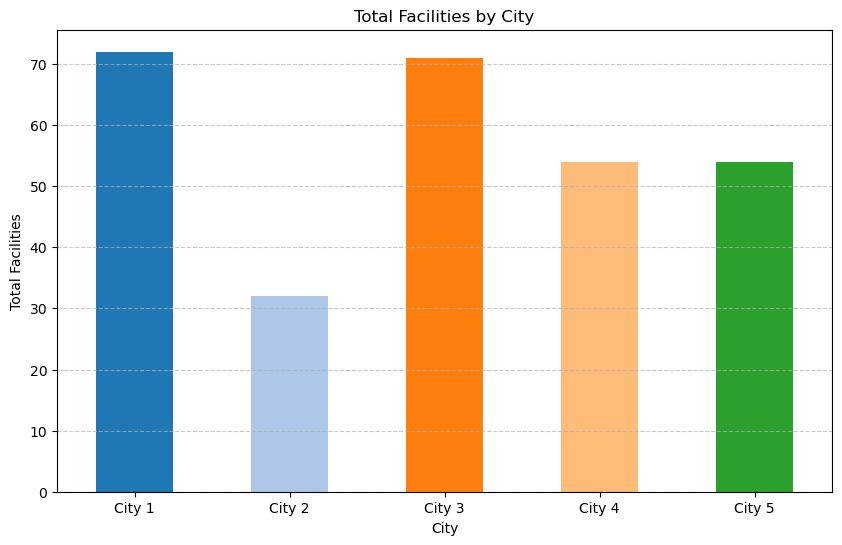

In [20]:
fig, ax = plt.subplots(figsize=(10, 6))
facility_summary_df.plot(kind='bar', 
                         y='Total Facilities', 
                         legend=False, 
                         color=colors[:len(facility_summary_df)],
                         ax=ax)
ax.set_title('Total Facilities by City')
ax.set_xlabel('City')
ax.tick_params(axis='x', rotation=0)
ax.set_ylabel('Total Facilities')
ax.grid(axis='y', linestyle='--', alpha=0.7)

Text(0, 0.5, 'Frequency')

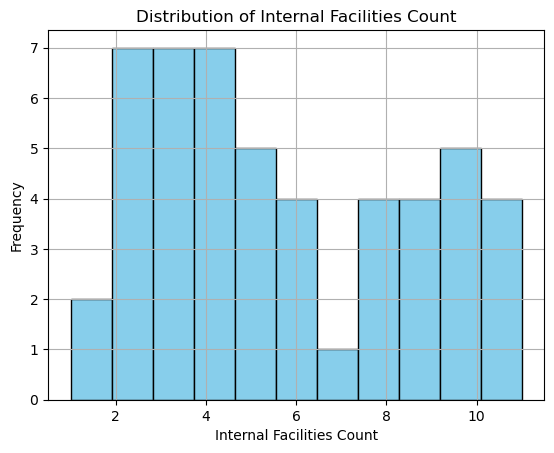

In [21]:
df['internalFacilitiesCount'].hist(bins=11, color='skyblue', edgecolor='black')
plt.title('Distribution of Internal Facilities Count')
plt.xlabel('Internal Facilities Count')
plt.ylabel('Frequency')

Text(0.5, 0, 'All Research Centers')

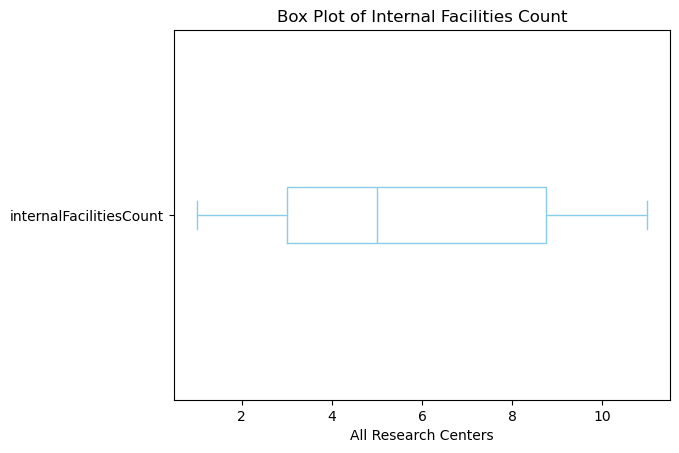

In [22]:
df['internalFacilitiesCount'].plot(kind='box', vert=False, color='skyblue')
plt.title('Box Plot of Internal Facilities Count')
plt.xlabel('All Research Centers')

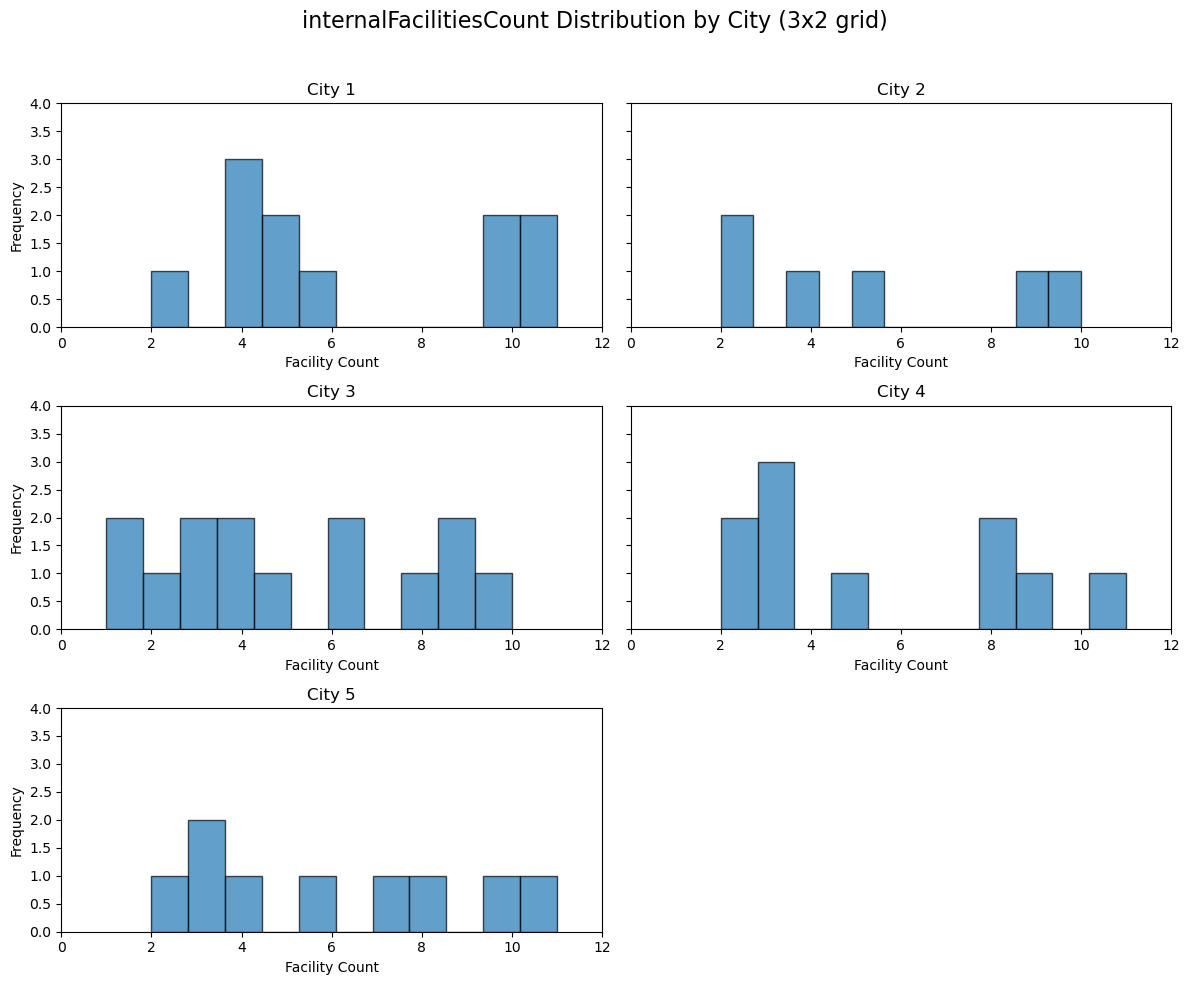

In [23]:
cities = df['city'].sort_values().unique()
max_bin_count = df['internalFacilitiesCount'].max()

fig, axes = plt.subplots(3, 2, figsize=(12, 10), sharex=False)
axes = axes.flatten()

for i, city in enumerate(cities):
    subset = df.loc[df['city'] == city, 'internalFacilitiesCount']
    subset.plot(
        kind='hist',
        bins=max_bin_count,
        ax=axes[i],
        edgecolor='black',
        alpha=0.7,
        title=city,
        sharex=False,
        sharey=True
    )
    axes[i].set_xlabel('Facility Count')
    axes[i].set_ylabel('Frequency')
    axes[i].set_xlim(0, max_bin_count + 1)
    axes[i].set_ylim(0, 4)

for j in range(len(cities), len(axes)):
    axes[j].axis('off')

fig.suptitle('internalFacilitiesCount Distribution by City (3x2 grid)', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

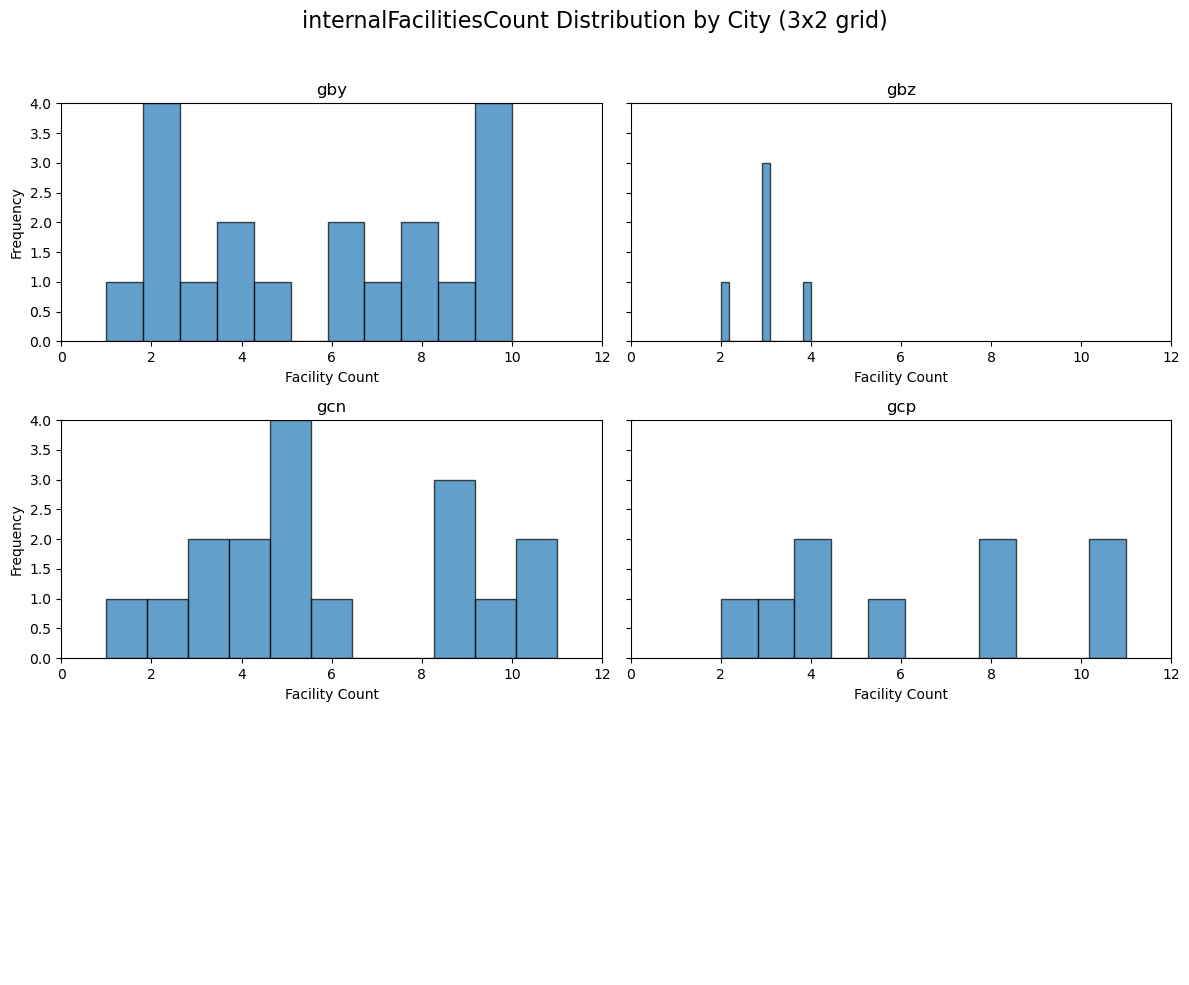

In [24]:
cities = df['geohash_3'].sort_values().unique()
max_bin_count = df['internalFacilitiesCount'].max()

fig, axes = plt.subplots(3, 2, figsize=(12, 10), sharex=False)
axes = axes.flatten()

for i, city in enumerate(cities):
    subset = df.loc[df['geohash_3'] == city, 'internalFacilitiesCount']
    subset.plot(
        kind='hist',
        bins=max_bin_count,
        ax=axes[i],
        edgecolor='black',
        alpha=0.7,
        title=city,
        sharex=False,
        sharey=True
    )
    axes[i].set_xlabel('Facility Count')
    axes[i].set_ylabel('Frequency')
    axes[i].set_xlim(0, max_bin_count + 1)
    axes[i].set_ylim(0, 4)

for j in range(len(cities), len(axes)):
    axes[j].axis('off')

fig.suptitle('internalFacilitiesCount Distribution by City (3x2 grid)', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

Text(0.5, 0.98, '')

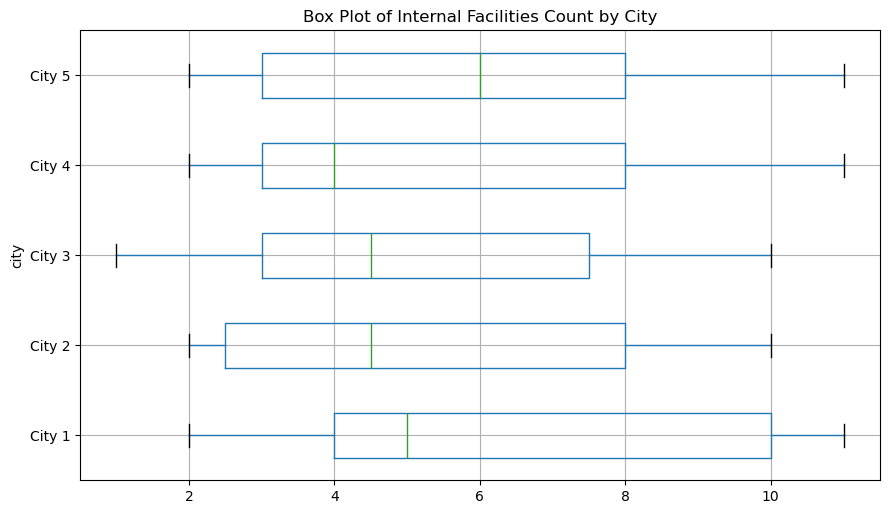

In [25]:
df.boxplot(column='internalFacilitiesCount', by='city', vert=False, figsize=(10, 6))
plt.title('Box Plot of Internal Facilities Count by City')
plt.suptitle('')

Text(0.5, 0.98, '')

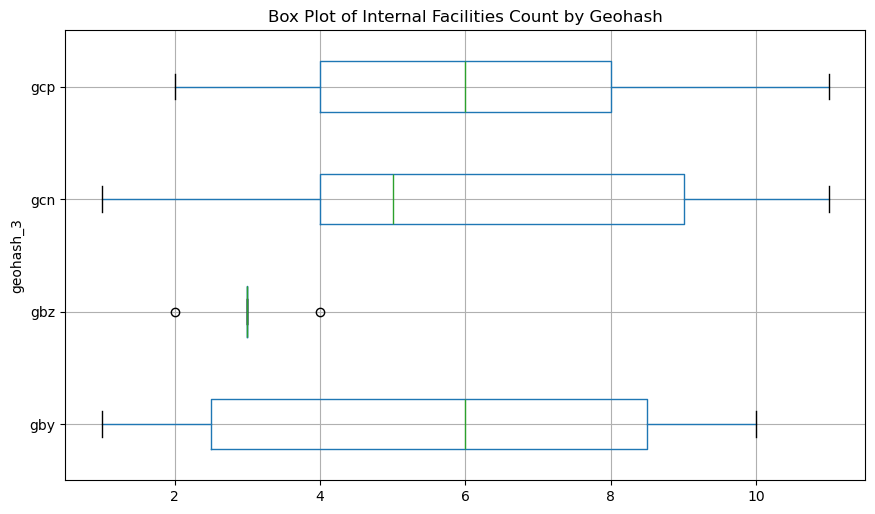

In [26]:
df.boxplot(column='internalFacilitiesCount', by='geohash_3', vert=False, figsize=(10, 6))
plt.title('Box Plot of Internal Facilities Count by Geohash')
plt.suptitle('')

### Hospital and pharmacies

In [27]:
df.groupby('city').agg(**{
    'Total Hospitals': ('hospitals_10km', 'sum'),
    'Total Pharmacies': ('pharmacies_10km', 'sum')
})

,Total Hospitals,Total Pharmacies
city,,
City 1,22,34
City 2,12,16
City 3,22,27
City 4,20,16
City 5,17,19


hospitals_10km        Axes(0.125,0.11;0.352273x0.77)
pharmacies_10km    Axes(0.547727,0.11;0.352273x0.77)
dtype: object

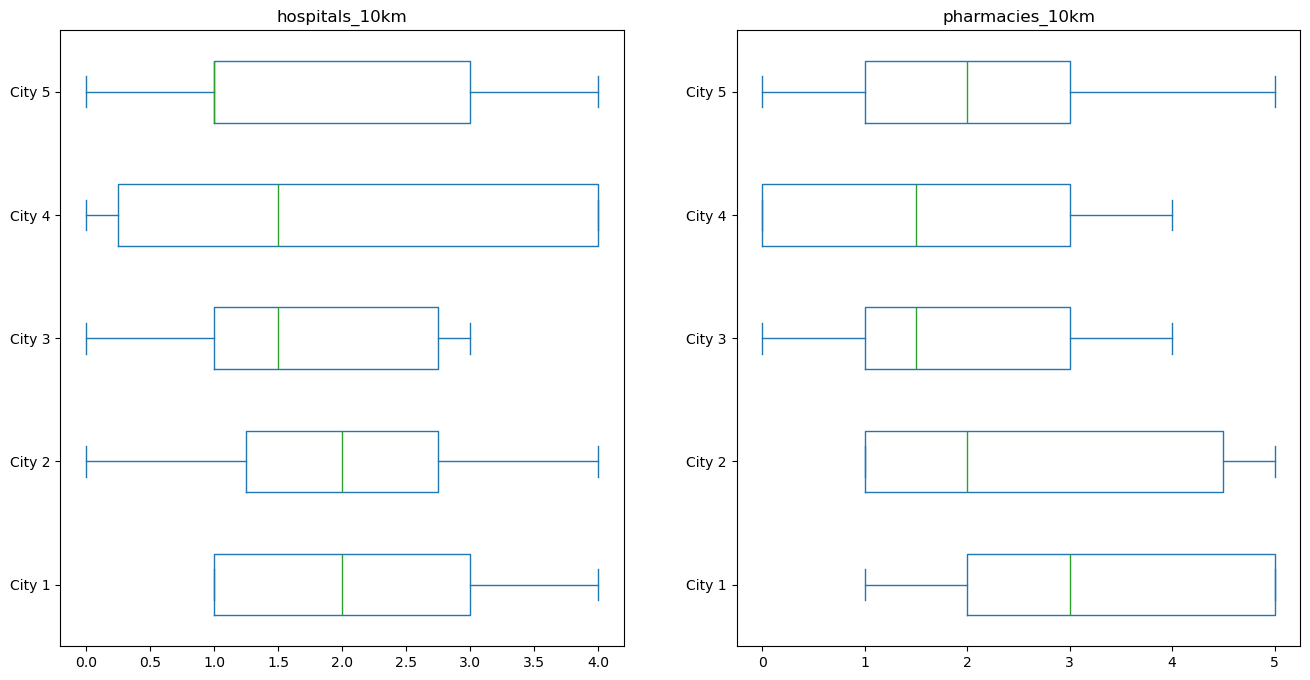

In [28]:
df.plot.box(column=['hospitals_10km', 'pharmacies_10km'], by='city', vert=False, figsize=(16, 8))

hospitals_10km        Axes(0.125,0.11;0.352273x0.77)
pharmacies_10km    Axes(0.547727,0.11;0.352273x0.77)
dtype: object

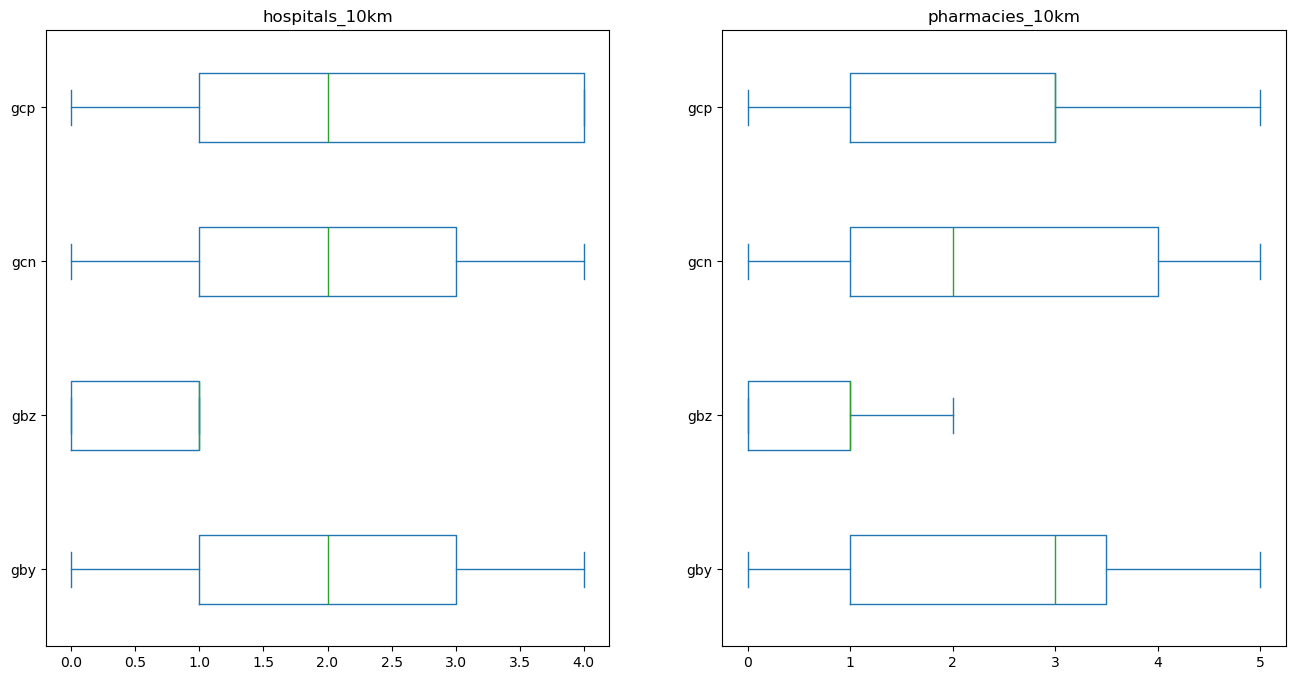

In [29]:
df.plot.box(column=['hospitals_10km', 'pharmacies_10km'], by='geohash_3', vert=False, figsize=(16, 8))

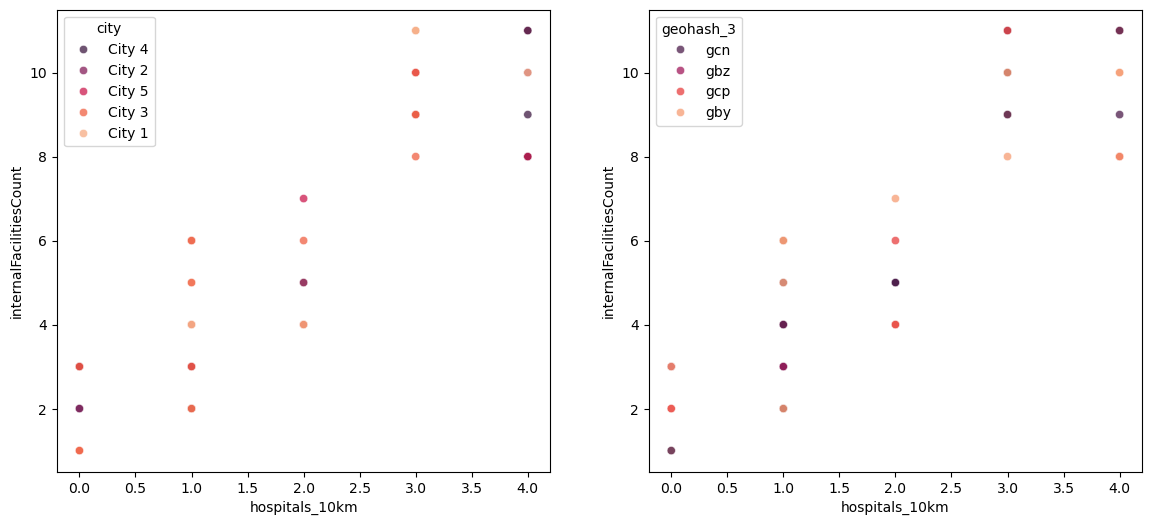

In [30]:
fig, ax = plt.subplots(figsize=(14, 6), ncols=2, nrows=1)
sns.scatterplot(
    data=df, 
    x='hospitals_10km', 
    y='internalFacilitiesCount', 
    hue='city',          
    palette='rocket', 
    alpha=0.75,
    ax=ax[0]
)
sns.scatterplot(
    data=df, 
    x='hospitals_10km', 
    y='internalFacilitiesCount', 
    hue='geohash_3',          
    palette='rocket', 
    alpha=0.75,
    ax=ax[1]
)
plt.show()

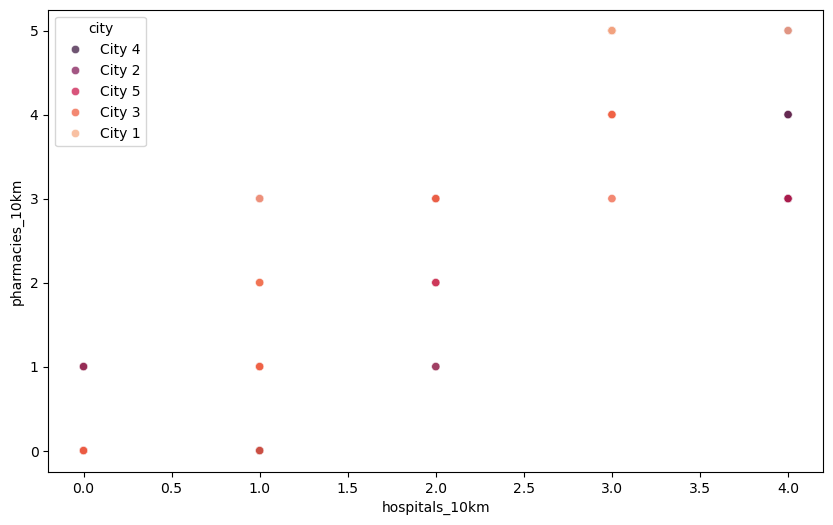

In [31]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df, 
    x='hospitals_10km', 
    y='pharmacies_10km', 
    hue='city',          
    palette='rocket', 
    alpha=0.75
)
plt.show()

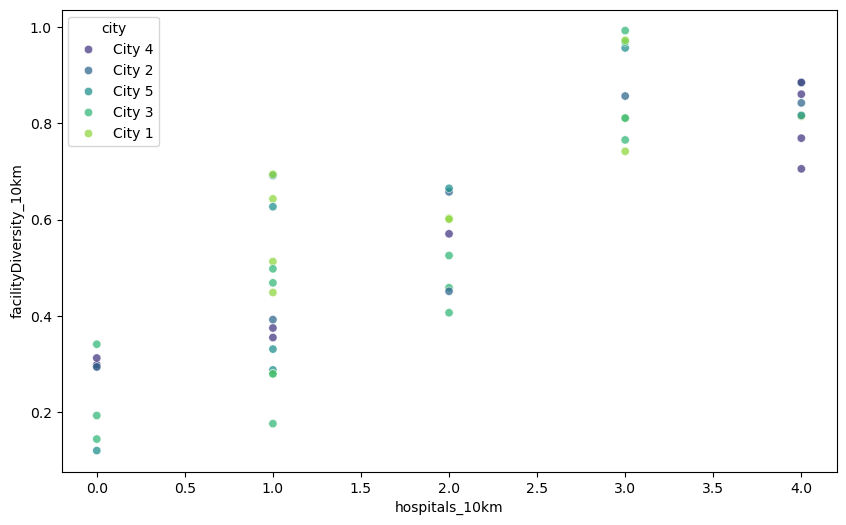

In [32]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df, 
    x='hospitals_10km', 
    y='facilityDiversity_10km', 
    hue='city',          
    palette='viridis', 
    alpha=0.75
)
plt.show()

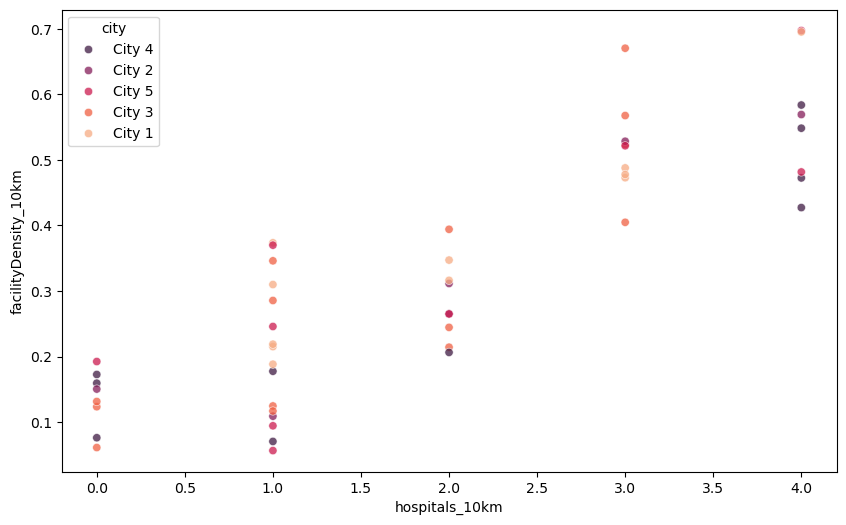

In [33]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df, 
    x='hospitals_10km', 
    y='facilityDensity_10km', 
    hue='city',          
    palette='rocket', 
    alpha=0.75
)
plt.show()

### Facility Diversity

<Axes: >

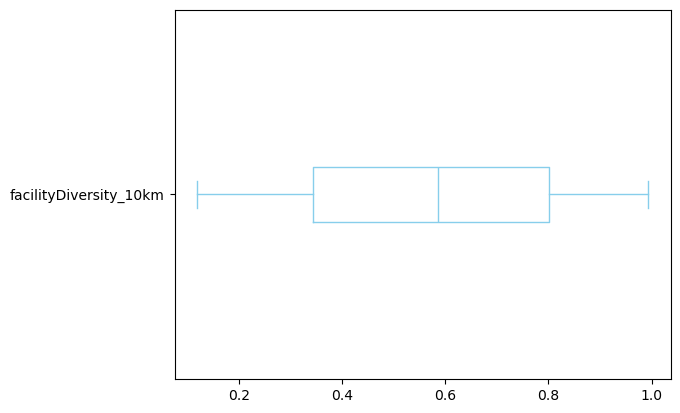

In [34]:
df['facilityDiversity_10km'].plot(kind='box', vert=False, color='skyblue')

facilityDiversity_10km    Axes(0.547727,0.11;0.352273x0.77)
dtype: object

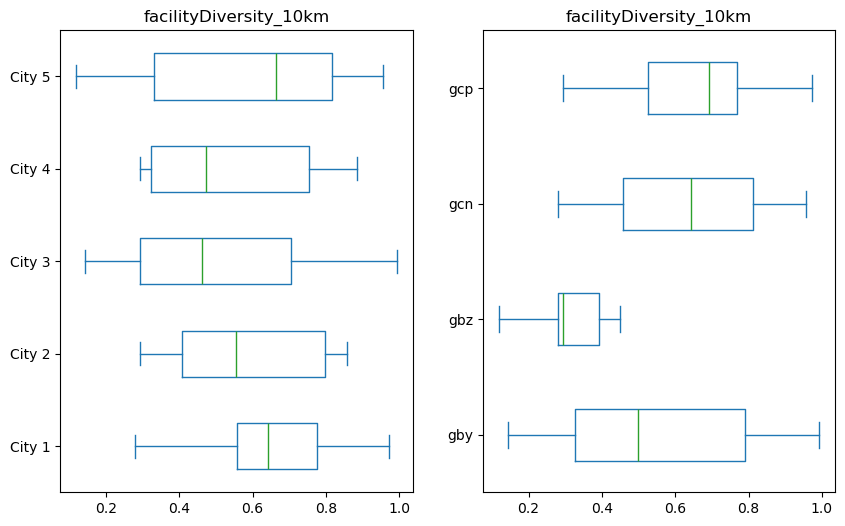

In [35]:
fig, ax = plt.subplots(figsize=(10, 6), ncols=2, nrows=1)
df.plot(kind='box', column='facilityDiversity_10km', by='city', vert=False, figsize=(14, 12), subplots=True, ax=ax[0])
df.plot(kind='box', column='facilityDiversity_10km', by='geohash_3', vert=False, figsize=(14, 12), subplots=True, ax=ax[1])

### Facility Density

facilityDensity_10km    Axes(0.547727,0.11;0.352273x0.77)
dtype: object

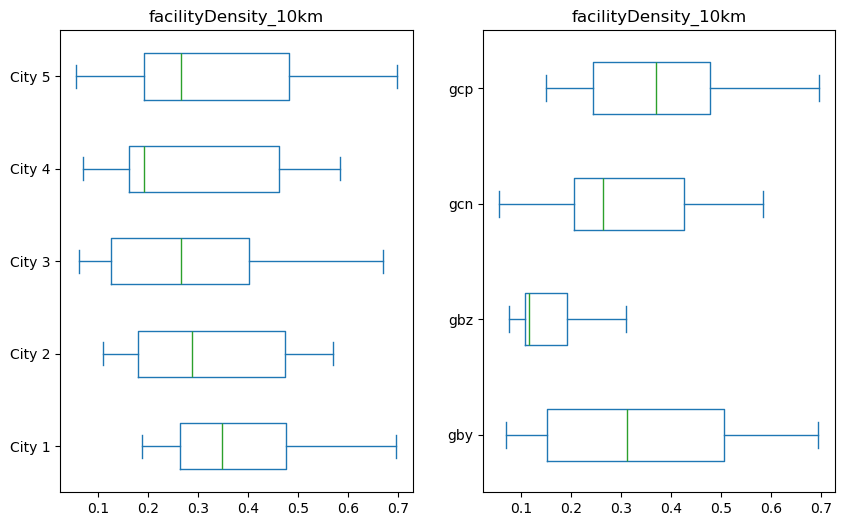

In [36]:
fig, ax = plt.subplots(figsize=(10, 6), ncols=2, nrows=1)
df.plot(kind='box', column='facilityDensity_10km', by='city', vert=False, figsize=(14, 12), ax=ax[0])
df.plot(kind='box', column='facilityDensity_10km', by='geohash_3', vert=False, figsize=(14, 12), ax=ax[1])

### Correlation

In [37]:
df.head()

,researchCenterName,city,latitude,longitude,internalFacilitiesCount,hospitals_10km,pharmacies_10km,facilityDiversity_10km,facilityDensity_10km,geohash_2,...,geohash_6,geohash_7,geohash_8,geohash_9,external_score,internal_external_ratio,healthcare_deficit,cart_x,cart_y,cart_z
researchCenterId,,,,,,,,,,,,,,,,,,,,,
RC-014,Research Center 14,City 4,50.7713,-1.9260,3,1,0,0.374488,0.177506,gc,...,gcn8u4,gcn8u4t,gcn8u4ts,gcn8u4ts2,1,1.500000,False,0.632060,-0.021255,0.774628
RC-040,Research Center 40,City 2,50.5088,-1.3637,2,1,1,0.391903,0.108965,gb,...,gbzp2f,gbzp2fy,gbzp2fyg,gbzp2fygp,2,0.666667,False,0.635780,-0.015135,0.771722
RC-031,Research Center 31,City 4,50.2202,-1.2889,3,0,1,0.293552,0.076155,gb,...,gbzjdw,gbzjdwm,gbzjdwm3,gbzjdwm3y,1,1.500000,False,0.639677,-0.014392,0.768509
RC-046,Research Center 46,City 5,50.9362,-1.3040,11,4,4,0.884502,0.697016,gc,...,gcp1f2,gcp1f2d,gcp1f2dk,gcp1f2dky,8,1.222222,False,0.630022,-0.014341,0.776445
RC-018,Research Center 18,City 2,50.0254,-1.8921,10,4,5,0.842611,0.568983,gb,...,gbyssf,gbyssfy,gbyssfy5,gbyssfy5n,9,1.000000,False,0.642098,-0.021212,0.766329


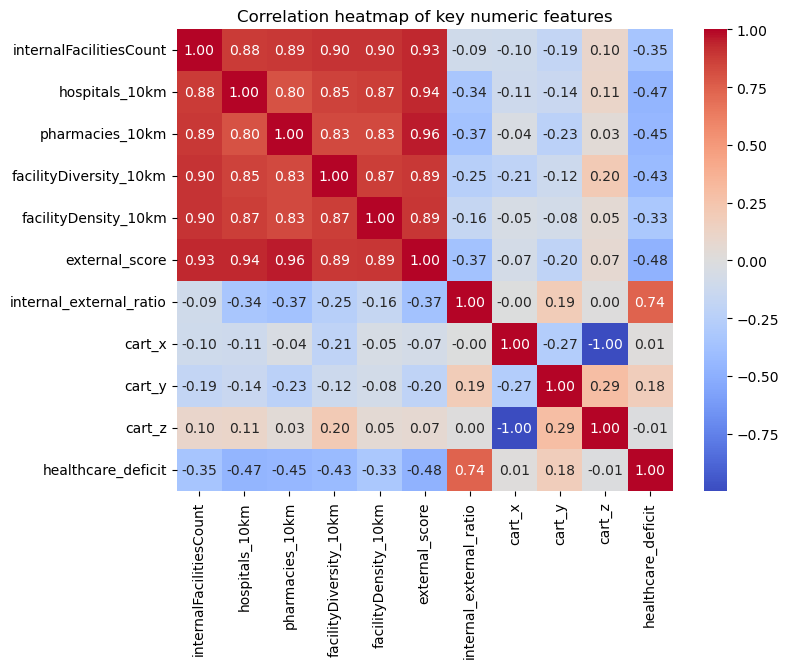

Correlation with facilityDiversity_10km:
 facilityDiversity_10km     1.000000
internalFacilitiesCount    0.903568
external_score             0.887116
facilityDensity_10km       0.868877
hospitals_10km             0.852964
pharmacies_10km            0.834209
cart_z                     0.204867
cart_y                    -0.123515
cart_x                    -0.207985
internal_external_ratio   -0.253400
healthcare_deficit        -0.426868
Name: facilityDiversity_10km, dtype: float64

Correlation with internalFacilitiesCount:
 internalFacilitiesCount    1.000000
external_score             0.931549
facilityDiversity_10km     0.903568
facilityDensity_10km       0.900576
pharmacies_10km            0.889402
hospitals_10km             0.878828
cart_z                     0.099889
internal_external_ratio   -0.094222
cart_x                    -0.104086
cart_y                    -0.186669
healthcare_deficit        -0.348829
Name: internalFacilitiesCount, dtype: float64


In [38]:
numeric_cols = ['internalFacilitiesCount','hospitals_10km','pharmacies_10km','facilityDiversity_10km','facilityDensity_10km', 'external_score', 'internal_external_ratio','cart_x', 'cart_y', 'cart_z', 'healthcare_deficit']
correlation = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation heatmap of key numeric features')
plt.show()

corr_with_diversity = correlation['facilityDiversity_10km'].sort_values(ascending=False)
corr_with_internal = correlation['internalFacilitiesCount'].sort_values(ascending=False)
print('Correlation with facilityDiversity_10km:\n', corr_with_diversity)
print('\nCorrelation with internalFacilitiesCount:\n', corr_with_internal)

# Feature Selection, Preprocessing, and K-Means Clustering

We will use scikit-learn transformers to build a pipeline that standardizes relevant numeric features and fits K-Means. This is purely unsupervised for now (no Gold labels), then we map clusters to `Premium`, `Standard`, `Basic` by center quality signal.

### Baseline Model

In [66]:
baseline_preprocessor = ColumnTransformer(
    transformers=[
        ('geographical', StandardScaler(), ['latitude', 'longitude']),
        ('categorical', OneHotEncoder(), ['city']),
        ('numerical', StandardScaler(), ['internalFacilitiesCount', 'hospitals_10km', 'pharmacies_10km', 'facilityDiversity_10km', 'facilityDensity_10km'])
    ],
    remainder='drop'
)

X_reference = baseline_preprocessor.fit_transform(df)

results = []
random_labels = np.random.randint(0, 3, size=len(df))
score = silhouette_score(X_reference, random_labels)
results.append({'experiment': 'Random Assignment', 'silhouette': score})

gmm = GaussianMixture(n_components=3, random_state=42)
labels = gmm.fit_predict(X_reference)
score = silhouette_score(X_reference, labels)
results.append({'experiment': 'GMM', 'silhouette': score})

baseline_df = pd.DataFrame(results)
baseline_df

,experiment,silhouette
0,Random Assignment,-0.044421
1,GMM,0.252523


### Phase 2

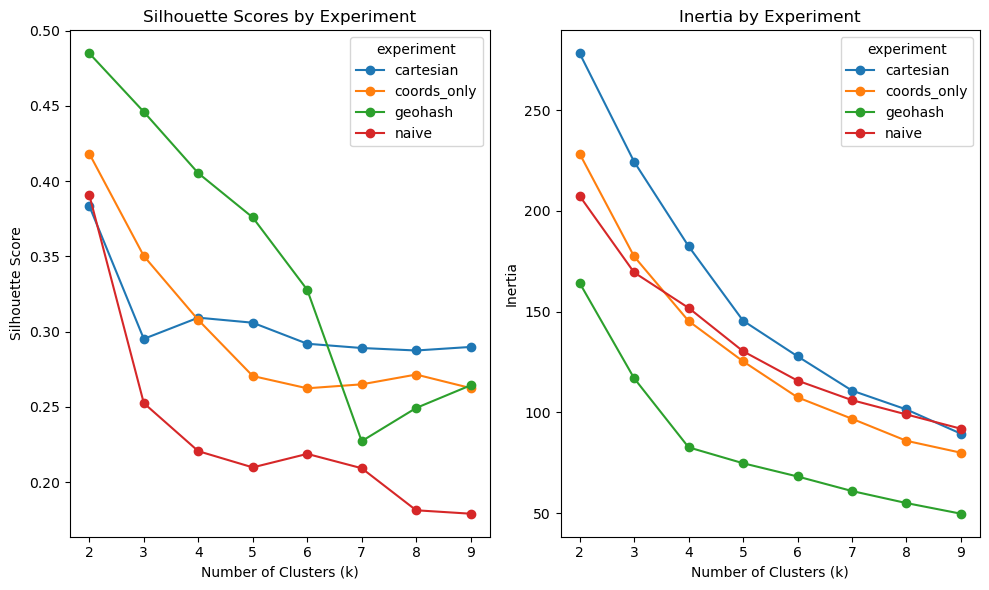

In [101]:
latitude_longitude_preprocessor = ColumnTransformer(
    transformers=[
        ('geographical', StandardScaler(), ['latitude', 'longitude']),
        ('numerical', StandardScaler(), ['internalFacilitiesCount', 'hospitals_10km', 'pharmacies_10km', 'facilityDiversity_10km', 'facilityDensity_10km', 'external_score', 'internal_external_ratio'])
    ],
    remainder='drop'
)

cart_preprocessor = ColumnTransformer(
    transformers=[
        ('numerical_geo', StandardScaler(), ['cart_x', 'cart_y', 'cart_z']),
        ('numerical', StandardScaler(), ['internalFacilitiesCount', 'hospitals_10km', 'pharmacies_10km', 'facilityDiversity_10km', 'facilityDensity_10km', 'external_score', 'internal_external_ratio'])
    ],
    remainder='drop'
)

geocache_preprocessor = ColumnTransformer(
    transformers=[
        ('categorical', OneHotEncoder(), ['geohash_3']),
        ('numerical', StandardScaler(), ['internalFacilitiesCount', 'hospitals_10km', 'pharmacies_10km', 'facilityDiversity_10km', 'facilityDensity_10km', 'external_score', 'internal_external_ratio'])
    ],
        remainder='drop'
)

experiments = {
    'naive': baseline_preprocessor,
    'coords_only': latitude_longitude_preprocessor,
    'cartesian': cart_preprocessor,
    'geohash': geocache_preprocessor
}

results = []
for name, transformer in experiments.items():
    X_processed = transformer.fit_transform(df)

    for k in range(2, 10):
        model = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = model.fit_predict(X_processed)
        score = silhouette_score(X_processed, labels)
        
        results.append({'experiment': name, 'k': k, 'silhouette': score, 'inertia': model.inertia_})

phase_2_exp = pd.DataFrame(results)

fig, ax = plt.subplots(figsize=(10, 6), ncols = 2, nrows=1)
exp_pivot_df = phase_2_exp.pivot(index='k', columns='experiment', values='silhouette')
exp_pivot_inertia_df = phase_2_exp.pivot(index='k', columns='experiment', values='inertia')
exp_pivot_df.plot(marker='o', ax=ax[0])
exp_pivot_inertia_df.plot(marker='o', ax=ax[1])
ax[0].set_title('Silhouette Scores by Experiment')
ax[0].set_xlabel('Number of Clusters (k)')
ax[0].set_ylabel('Silhouette Score')
ax[1].set_title('Inertia by Experiment')
ax[1].set_xlabel('Number of Clusters (k)')
ax[1].set_ylabel('Inertia')
plt.tight_layout()

warnings.filterwarnings("ignore", category=UserWarning)

In [64]:
geo_cols = ['latitude', 'longitude', 'city', 'geohash_2', 'geohash_3', 'geohash_4', 'geohash_5', 'geohash_6', 'geohash_7', 'geohash_8', 'geohash_9', 'cart_x', 'cart_y', 'cart_z']
num_cols = ['internalFacilitiesCount', 'hospitals_10km', 'pharmacies_10km', 'facilityDiversity_10km', 'facilityDensity_10km', 'external_score', 'internal_external_ratio']

experiments = {
    'baseline': baseline_preprocessor,
    'simple_geohash': geocache_preprocessor,
}

for geocache_num in range(2, 10):
    for pca_num in range(2, 10):
        target_col = f'geohash_{geocache_num}'
        to_drop = ['researchCenterName'] + [c for c in geo_cols if c != target_col]
        
        base_transformer = ColumnTransformer([
            ('drop', 'drop', to_drop),
            ('geo_cat', OneHotEncoder(), [target_col]),
            ('numerical', StandardScaler(), num_cols)
        ])
        
        experiments[f'geohash_{geocache_num}_pca_{pca_num}'] = Pipeline([
            ('prep', base_transformer),
            ('pca', PCA(n_components=pca_num, random_state=42))
        ])

results = []
for name, transformer in experiments.items():
    X_processed = transformer.fit_transform(df)

    for k in range(2, 10):
        model = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = model.fit_predict(X_processed)
        score = silhouette_score(X_processed, labels)
        
        results.append({'experiment': name, 'k': k, 'silhouette': score, 'inertia': model.inertia_})

phase_3_exp = pd.DataFrame(results)
phase_3_exp[phase_3_exp['k'] == 3].sort_values(by='silhouette', ascending=False).head()


,experiment,k,silhouette,inertia
209,geohash_5_pca_2,3,0.609736,59.010703
465,geohash_9_pca_2,3,0.609644,59.047757
401,geohash_8_pca_2,3,0.609644,59.047757
273,geohash_6_pca_2,3,0.609644,59.047757
337,geohash_7_pca_2,3,0.609644,59.047757


In [77]:
master_results_df = pd.concat([phase_3_exp.sort_values(by='silhouette', ascending=False).head(1), 
           phase_3_exp[phase_3_exp['k'] == 3].sort_values(by='silhouette', ascending=False).head(1),
           baseline_df]).fillna('N/A').reset_index(drop=True)
master_results_df

,experiment,k,silhouette,inertia
0,geohash_2_pca_2,5.0,0.655352,17.66944
1,geohash_5_pca_2,3.0,0.609736,59.010703
2,Random Assignment,N/A,-0.044421,N/A
3,GMM,N/A,0.252523,N/A


In [ ]:
exp_pivot_df = phase_3_exp.pivot(index='k', columns='experiment', values='silhouette')
exp_pivot_inertia_df = phase_3_exp.pivot(index='k', columns='experiment', values='inertia')

experiments_list = list(exp_pivot_df.columns)

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=('Silhouette Scores by Experiment', 'Inertia by Experiment'),
    horizontal_spacing=0.12
)

for experiment in experiments_list:
    fig.add_trace(
        go.Scatter(
            x=exp_pivot_df.index,
            y=exp_pivot_df[experiment],
            mode='lines+markers',
            name=experiment,
            legendgroup=experiment,
            visible=True,
            line=dict(width=2),
            marker=dict(size=8),
            hovertemplate=f'<b>{experiment}</b><br>k=%{{x}}<br>Silhouette=%{{y:.3f}}<extra></extra>'
        ),
        row=1, col=1
    )
    
    fig.add_trace(
        go.Scatter(
            x=exp_pivot_inertia_df.index,
            y=exp_pivot_inertia_df[experiment],
            mode='lines+markers',
            name=experiment,
            legendgroup=experiment,
            showlegend=False,
            visible=True,
            line=dict(width=2),
            marker=dict(size=8),
            hovertemplate=f'<b>{experiment}</b><br>k=%{{x}}<br>Inertia=%{{y:.0f}}<extra></extra>'
        ),
        row=1, col=2
    )

fig.update_layout(
    title_text="Clustering Evaluation Metrics",
    height=500,
    width=1200,
    hovermode='closest',
    legend=dict(
        title="Experiments",
        yanchor="top",
        y=0.99,
        xanchor="left",
        x=1.02,
        bgcolor="rgba(255, 255, 255, 0.8)",
        bordercolor="black",
        borderwidth=1
    )
)

fig.update_xaxes(title_text="Number of Clusters (k)", row=1, col=1)
fig.update_xaxes(title_text="Number of Clusters (k)", row=1, col=2)
fig.update_yaxes(title_text="Silhouette Score", row=1, col=1)
fig.update_yaxes(title_text="Inertia", row=1, col=2)

dropdown_buttons = []
for experiment in experiments_list:
    visibility = []
    for exp in experiments_list:
        visibility.append(exp == experiment)
    visibility = visibility + visibility
    
    dropdown_buttons.append(
        dict(
            label=experiment,
            method="update",
            args=[{"visible": visibility}]
        )
    )

# Add "Show All" button
all_visible = [True] * (len(experiments_list) * 2)
dropdown_buttons.insert(0, dict(
    label="Show All",
    method="update",
    args=[{"visible": all_visible}]
))

fig.update_layout(
    updatemenus=[
        dict(
            buttons=dropdown_buttons,
            direction="down",
            showactive=True,
            x=0.02,
            y=1.15,
            xanchor="left",
            yanchor="top",
            bgcolor="white",
            bordercolor="black",
            borderwidth=1,
            font=dict(size=12)
        )
    ]
)

fig.show()

# Analysis

c:\Users\maran\anaconda3\envs\assess_grid_research\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\maran\anaconda3\envs\assess_grid_research\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


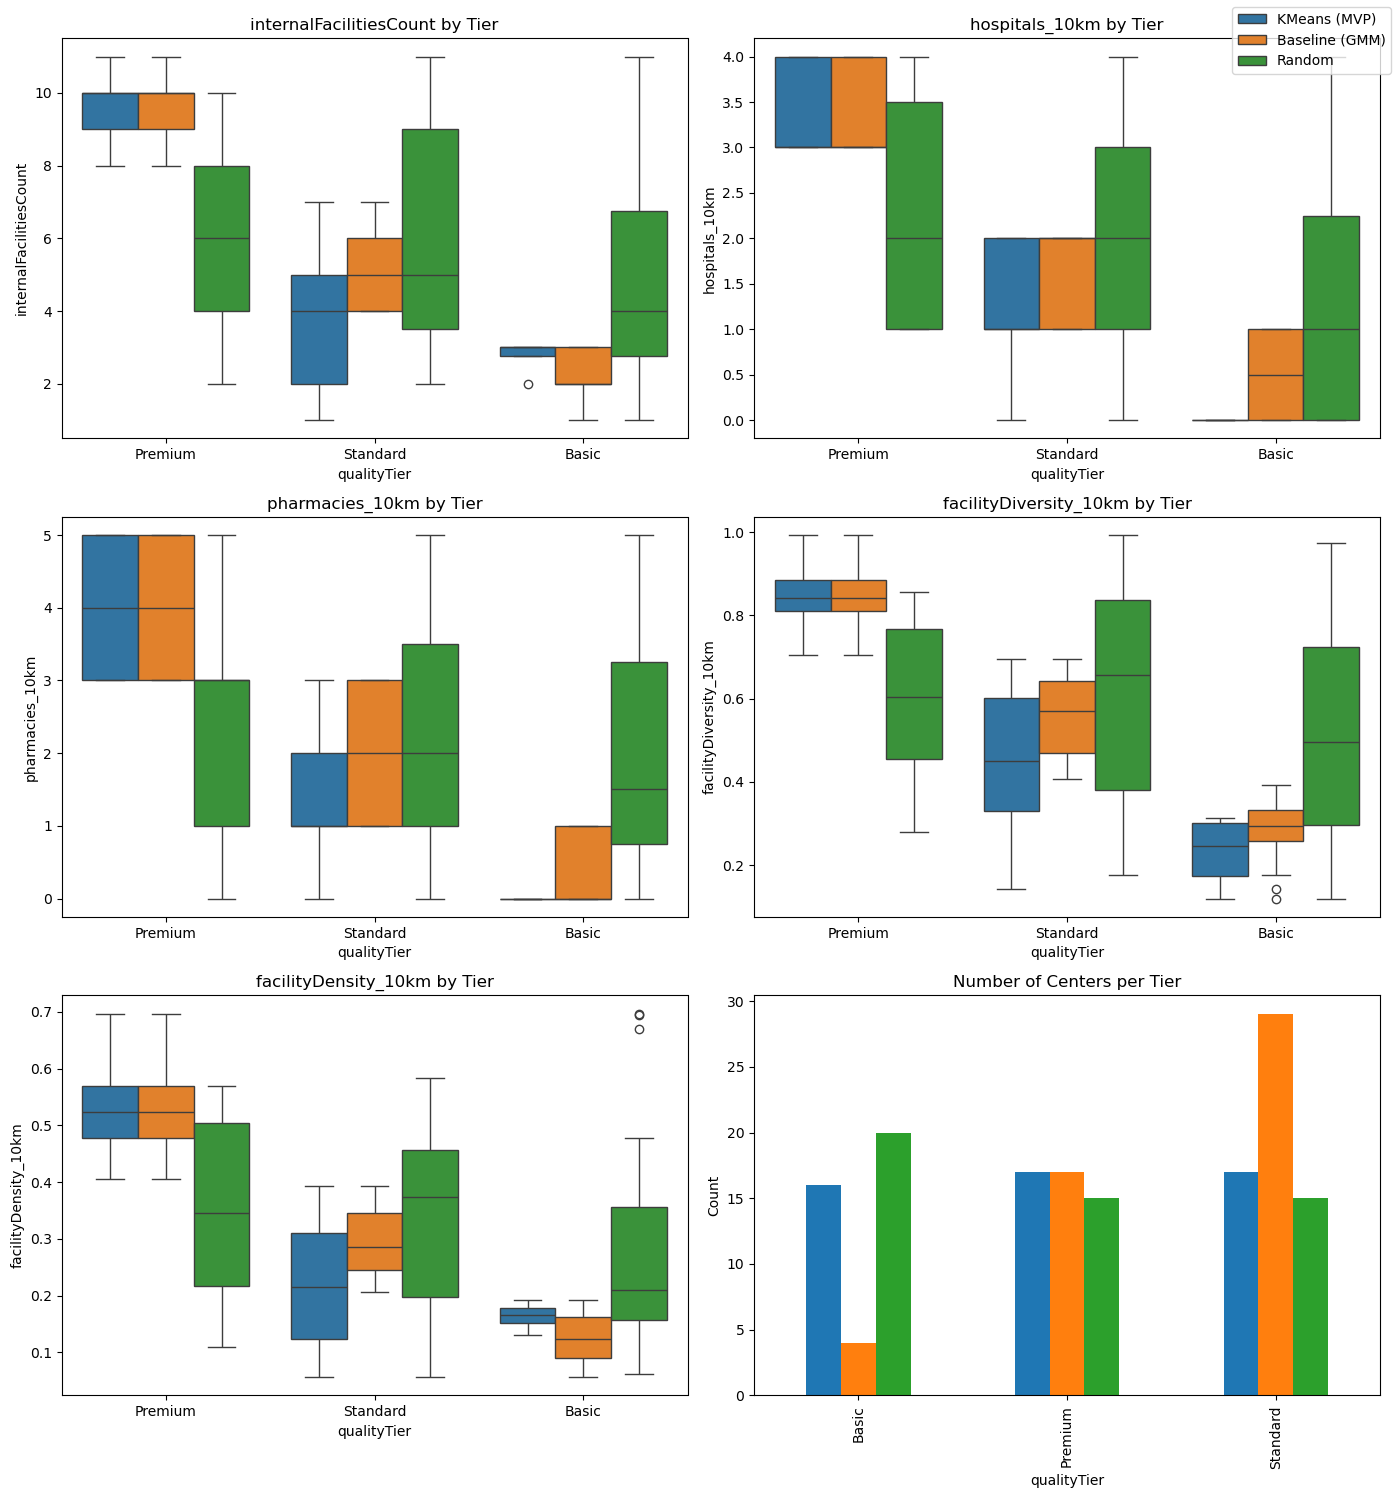

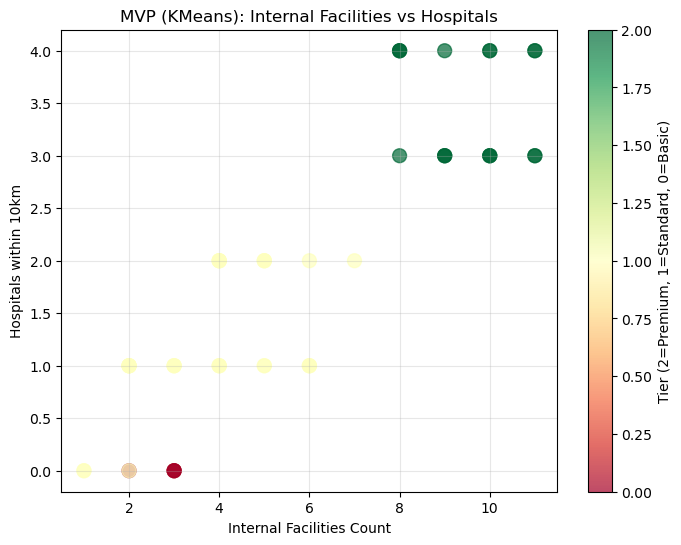

In [43]:
# =========================
# FINAL MODEL (KMEANS MVP)
# =========================
mvp_exp = phase_3_exp[phase_3_exp['k'] == 3] \
    .sort_values(by='silhouette', ascending=False) \
    .reset_index(drop=True).loc[0, 'experiment']

final_pipeline = Pipeline([
    ('preprocessor', experiments[mvp_exp]),
    ('kmeans', KMeans(n_clusters=3, random_state=42, n_init=10))
])

final_pipeline.fit(df)

df_kmeans = df.copy()
df_kmeans['cluster'] = final_pipeline.named_steps['kmeans'].labels_

# Quality score
def compute_quality(df_):
    return (
        df_['internalFacilitiesCount'] * 0.3 +
        df_['hospitals_10km'] * 0.2 +
        df_['pharmacies_10km'] * 0.15 +
        df_['facilityDiversity_10km'] * 0.2 +
        df_['facilityDensity_10km'] * 0.15
    )

df_kmeans['quality_score'] = compute_quality(df_kmeans)

# Map clusters → tiers
tiers = ['Basic', 'Standard', 'Premium']
cluster_quality = df_kmeans.groupby('cluster')['quality_score'].mean().sort_values()

mapping_kmeans = {}
for i, (cluster, _) in enumerate(cluster_quality.items()):
    mapping_kmeans[cluster] = tiers[i]

df_kmeans['qualityTier'] = df_kmeans['cluster'].map(mapping_kmeans)
df_kmeans['model'] = 'KMeans (MVP)'


# =========================
# BASELINE (GMM)
# =========================
baseline_preprocessor = ColumnTransformer(
    transformers=[
        ('geo', StandardScaler(), ['latitude', 'longitude']),
        ('cat', OneHotEncoder(), ['city']),
        ('num', StandardScaler(), [
            'internalFacilitiesCount', 'hospitals_10km', 'pharmacies_10km',
            'facilityDiversity_10km', 'facilityDensity_10km'
        ])
    ]
)

X_ref = baseline_preprocessor.fit_transform(df)

df_gmm = df.copy()
gmm = GaussianMixture(n_components=3, random_state=42)
df_gmm['cluster'] = gmm.fit_predict(X_ref)

df_gmm['quality_score'] = compute_quality(df_gmm)

cluster_quality_gmm = df_gmm.groupby('cluster')['quality_score'].mean().sort_values()

mapping_gmm = {}
for i, (cluster, _) in enumerate(cluster_quality_gmm.items()):
    mapping_gmm[cluster] = tiers[i]

df_gmm['qualityTier'] = df_gmm['cluster'].map(mapping_gmm)
df_gmm['model'] = 'Baseline (GMM)'


# =========================
# RANDOM BASELINE
# =========================
df_random = df.copy()

np.random.seed(42)
df_random['cluster'] = np.random.randint(0, 3, size=len(df_random))

df_random['quality_score'] = compute_quality(df_random)

cluster_quality_rand = df_random.groupby('cluster')['quality_score'].mean().sort_values()

mapping_rand = {}
for i, (cluster, _) in enumerate(cluster_quality_rand.items()):
    mapping_rand[cluster] = tiers[i]

df_random['qualityTier'] = df_random['cluster'].map(mapping_rand)
df_random['model'] = 'Random'


# =========================
# COMBINE ALL
# =========================
combined_df = pd.concat([df_kmeans, df_gmm, df_random], ignore_index=True)


# =========================
# BOXPLOTS (2 COLUMNS GRID)
# =========================
features = [
    'internalFacilitiesCount',
    'hospitals_10km',
    'pharmacies_10km',
    'facilityDiversity_10km',
    'facilityDensity_10km'
]

n_plots = len(features) + 1  # +1 for count plot
n_cols = 2
n_rows = int(np.ceil(n_plots / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.boxplot(
        data=combined_df,
        x='qualityTier',
        y=feature,
        hue='model',
        order=['Premium', 'Standard', 'Basic'],
        ax=axes[i]
    )
    axes[i].set_title(f'{feature} by Tier')

# Count plot
tier_counts = combined_df.groupby(['qualityTier', 'model']).size().unstack()
tier_counts.plot(kind='bar', ax=axes[len(features)])
axes[len(features)].set_title('Number of Centers per Tier')
axes[len(features)].set_ylabel('Count')

# Clean legends
for ax in axes:
    if ax.get_legend():
        ax.get_legend().remove()

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right')

plt.tight_layout()
plt.show()


# =========================
# SCATTER (ONLY MVP)
# =========================
plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    df_kmeans['internalFacilitiesCount'],
    df_kmeans['hospitals_10km'],
    c=df_kmeans['qualityTier'].map({'Premium': 2, 'Standard': 1, 'Basic': 0}),
    cmap='RdYlGn',
    alpha=0.7,
    s=100
)

plt.xlabel('Internal Facilities Count')
plt.ylabel('Hospitals within 10km')
plt.title('MVP (KMeans): Internal Facilities vs Hospitals')

plt.colorbar(scatter, label='Tier (2=Premium, 1=Standard, 0=Basic)')
plt.grid(True, alpha=0.3)
plt.show()

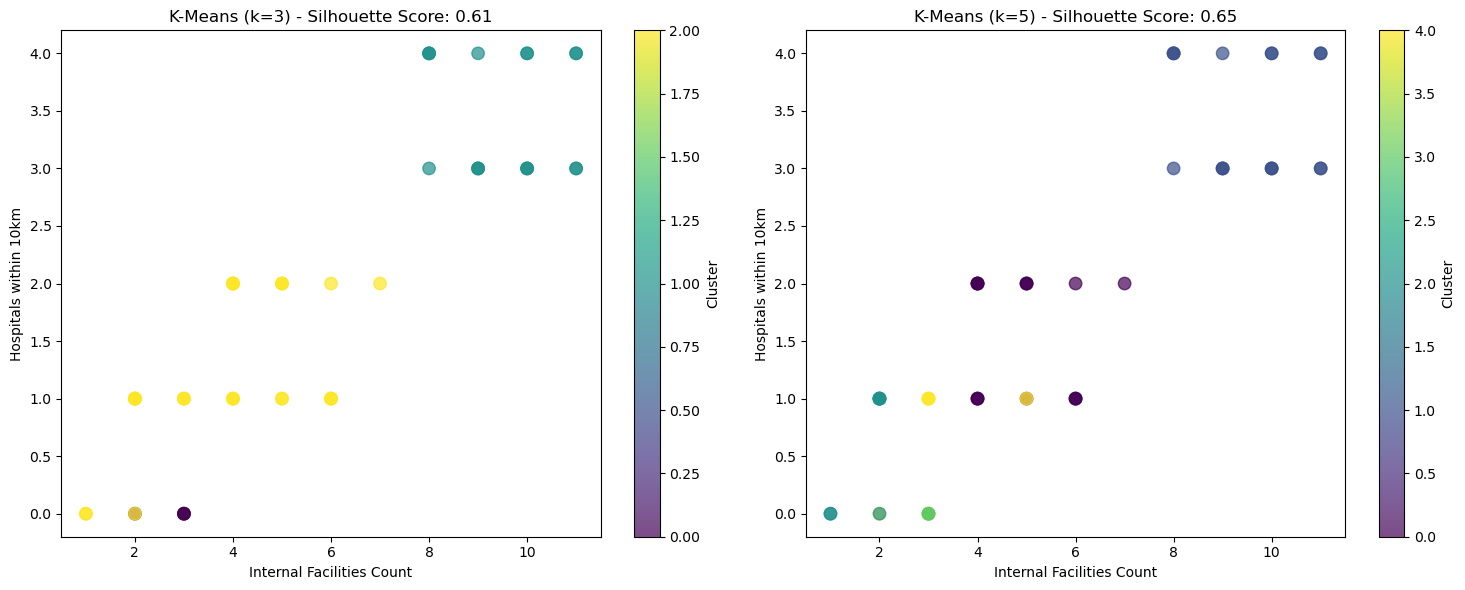

In [93]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# K=3 model (from df_kmeans)
scatter1 = axes[0].scatter(
    df_kmeans['internalFacilitiesCount'], 
    df_kmeans['hospitals_10km'], 
    c=df_kmeans['cluster'], 
    cmap='viridis', 
    alpha=0.7,
    s=80
)
axes[0].set_title('K-Means (k=3) - Silhouette Score: 0.61')
axes[0].set_xlabel('Internal Facilities Count')
axes[0].set_ylabel('Hospitals within 10km')
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

# K=5 model (re-run with k=5)
X_processed_5 = experiments[mvp_exp].fit_transform(df)
kmeans_5 = KMeans(n_clusters=5, random_state=42, n_init=10)
df_kmeans_5 = df.copy()
df_kmeans_5['cluster'] = kmeans_5.fit_predict(X_processed_5)

scatter2 = axes[1].scatter(
    df_kmeans_5['internalFacilitiesCount'], 
    df_kmeans_5['hospitals_10km'], 
    c=df_kmeans_5['cluster'], 
    cmap='viridis', 
    alpha=0.7,
    s=80
)
axes[1].set_title('K-Means (k=5) - Silhouette Score: 0.65')
axes[1].set_xlabel('Internal Facilities Count')
axes[1].set_ylabel('Hospitals within 10km')
plt.colorbar(scatter2, ax=axes[1], label='Cluster')

plt.tight_layout()
plt.show()

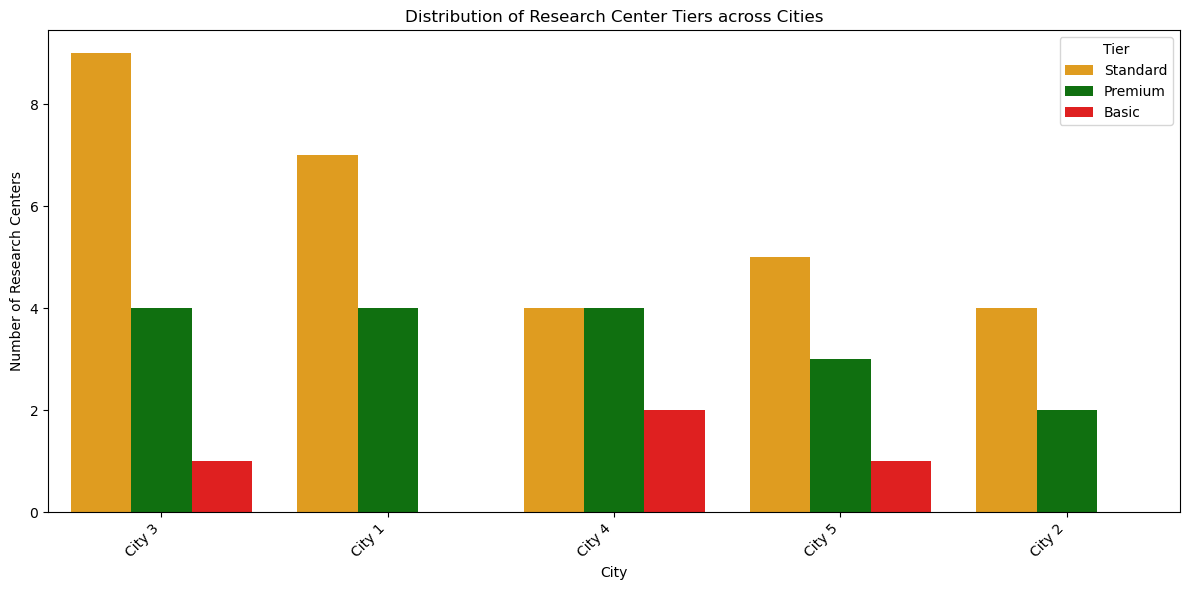

In [94]:
plt.figure(figsize=(12, 6))
city_order = df_kmeans.groupby('city')['qualityTier'].count().sort_values(ascending=False).index

sns.countplot(
    data=df_kmeans, 
    x='city', 
    hue='qualityTier', 
    order=city_order,
    palette={'Premium': 'green', 'Standard': 'orange', 'Basic': 'red'}
)
plt.title('Distribution of Research Center Tiers across Cities')
plt.xlabel('City')
plt.ylabel('Number of Research Centers')
plt.legend(title='Tier')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

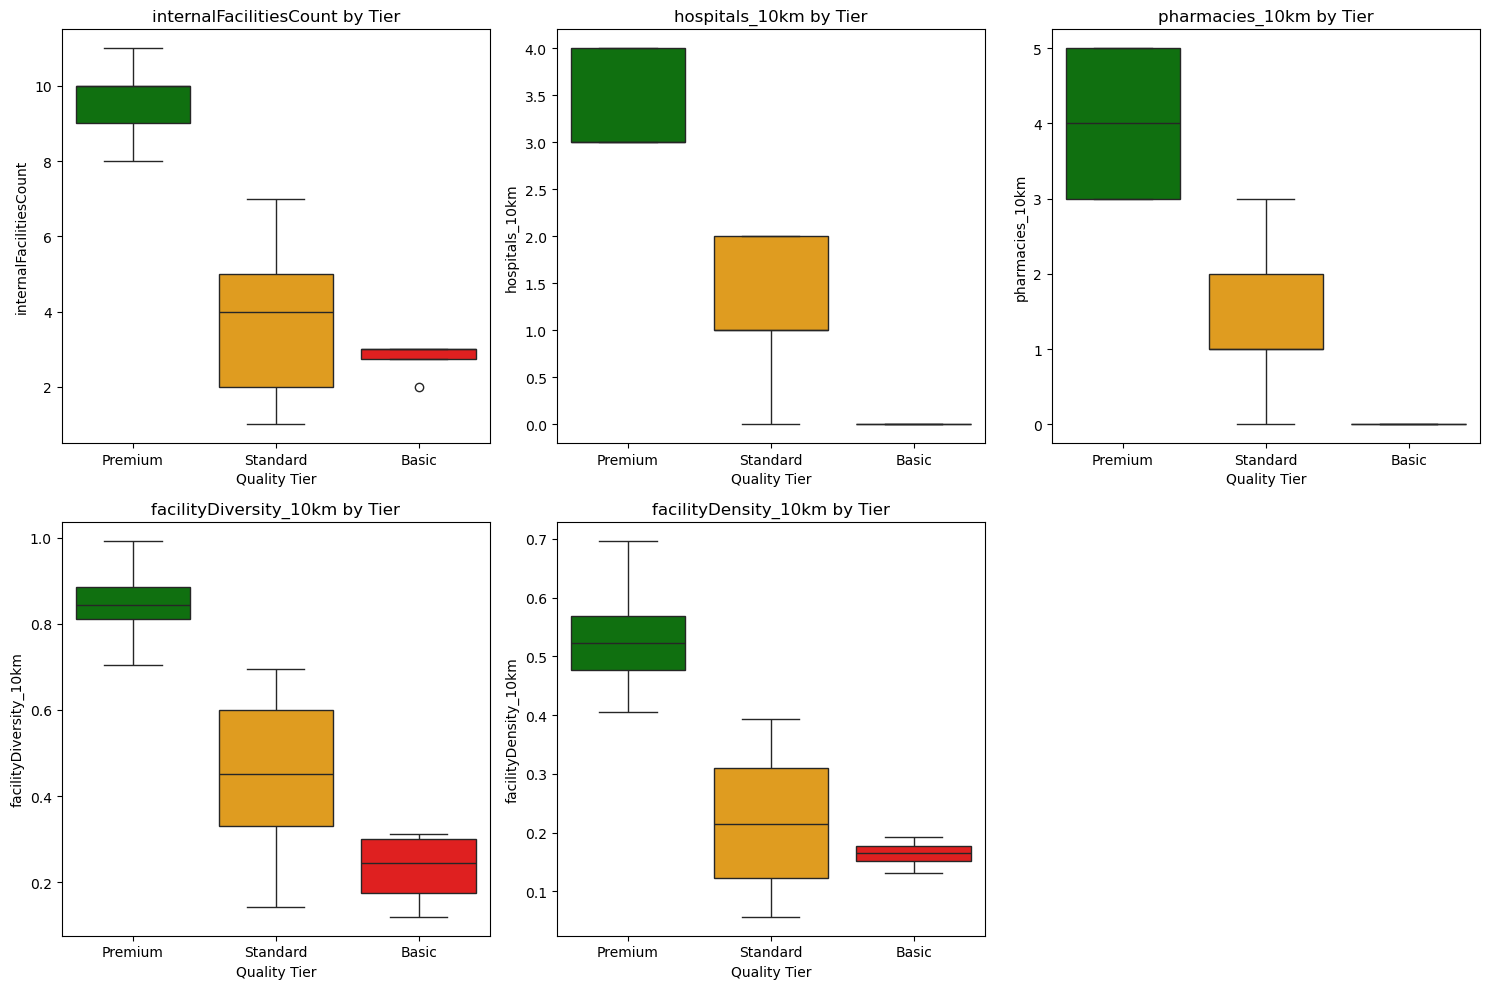

In [95]:
features_to_plot = [
    'internalFacilitiesCount',
    'hospitals_10km',
    'pharmacies_10km',
    'facilityDiversity_10km',
    'facilityDensity_10km'
]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, feature in enumerate(features_to_plot):
    sns.boxplot(
        data=df_kmeans, 
        x='qualityTier', 
        y=feature, 
        order=['Premium', 'Standard', 'Basic'],
        palette={'Premium': 'green', 'Standard': 'orange', 'Basic': 'red'},
        ax=axes[i]
    )
    axes[i].set_title(f'{feature} by Tier')
    axes[i].set_xlabel('Quality Tier')
    axes[i].set_ylabel(feature)

# Remove extra subplot
if len(features_to_plot) < len(axes):
    axes[-1].set_visible(False)

plt.tight_layout()
plt.show()

Most important

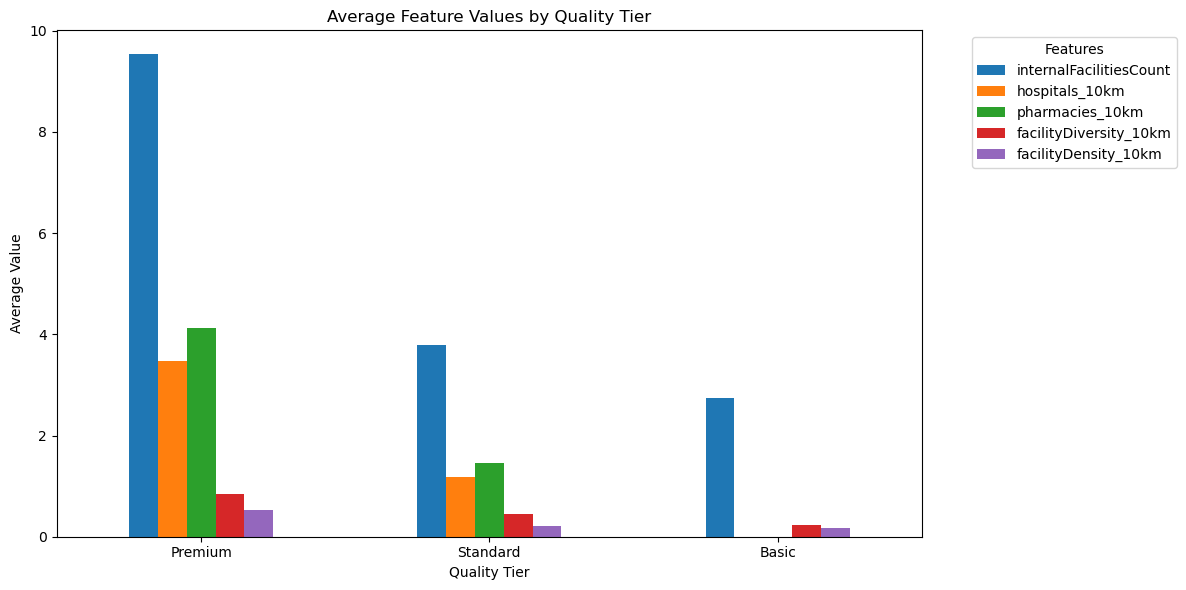

In [97]:
tier_means = df_kmeans.groupby('qualityTier')[features_to_plot].mean()
tier_means = tier_means.reindex(['Premium', 'Standard', 'Basic'])

tier_means.plot(kind='bar', figsize=(12, 6))
plt.title('Average Feature Values by Quality Tier')
plt.xlabel('Quality Tier')
plt.ylabel('Average Value')
plt.legend(title='Features', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Average cluster stability: 0.484
Stability range: 0.400 to 0.600


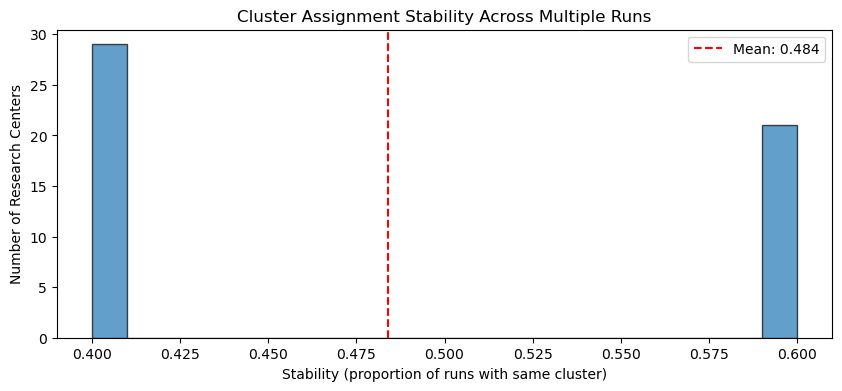

In [98]:
n_runs = 10
random_seeds = [42, 123, 456, 789, 101112, 131415, 161718, 192021, 222324, 252627]

X_processed_stability = experiments[mvp_exp].fit_transform(df)

cluster_labels_stability = []
for seed in random_seeds:
    kmeans_temp = KMeans(n_clusters=3, random_state=seed, n_init=10)
    labels_temp = kmeans_temp.fit_predict(X_processed_stability)
    cluster_labels_stability.append(labels_temp)

labels_df_stability = pd.DataFrame(cluster_labels_stability).T
mode_labels_stability = labels_df_stability.mode(axis=1)[0]
stability_scores = (labels_df_stability == mode_labels_stability.values.reshape(-1, 1)).mean(axis=1)

print(f"Average cluster stability: {stability_scores.mean():.3f}")
print(f"Stability range: {stability_scores.min():.3f} to {stability_scores.max():.3f}")

plt.figure(figsize=(10, 4))
plt.hist(stability_scores, bins=20, alpha=0.7, edgecolor='black')
plt.axvline(x=stability_scores.mean(), color='red', linestyle='--', label=f'Mean: {stability_scores.mean():.3f}')
plt.xlabel('Stability (proportion of runs with same cluster)')
plt.ylabel('Number of Research Centers')
plt.title('Cluster Assignment Stability Across Multiple Runs')
plt.legend()
plt.show()

In [112]:
df_kmeans.head()

,researchCenterName,city,latitude,longitude,internalFacilitiesCount,hospitals_10km,pharmacies_10km,facilityDiversity_10km,facilityDensity_10km,geohash_2,...,external_score,internal_external_ratio,healthcare_deficit,cart_x,cart_y,cart_z,cluster,quality_score,qualityTier,model
researchCenterId,,,,,,,,,,,,,,,,,,,,,
RC-014,Research Center 14,City 4,50.7713,-1.9260,3,1,0,0.374488,0.177506,gc,...,1,1.500000,False,0.632060,-0.021255,0.774628,2,1.201523,Standard,KMeans (MVP)
RC-040,Research Center 40,City 2,50.5088,-1.3637,2,1,1,0.391903,0.108965,gb,...,2,0.666667,False,0.635780,-0.015135,0.771722,2,1.044725,Standard,KMeans (MVP)
RC-031,Research Center 31,City 4,50.2202,-1.2889,3,0,1,0.293552,0.076155,gb,...,1,1.500000,False,0.639677,-0.014392,0.768509,2,1.120134,Standard,KMeans (MVP)
RC-046,Research Center 46,City 5,50.9362,-1.3040,11,4,4,0.884502,0.697016,gc,...,8,1.222222,False,0.630022,-0.014341,0.776445,1,4.981453,Premium,KMeans (MVP)
RC-018,Research Center 18,City 2,50.0254,-1.8921,10,4,5,0.842611,0.568983,gb,...,9,1.000000,False,0.642098,-0.021212,0.766329,1,4.803870,Premium,KMeans (MVP)


In [110]:
df_kmeans.groupby('qualityTier').agg(**{
    'Total Internal Facilities': ('internalFacilitiesCount', 'sum'),
    'Total Hospitals': ('hospitals_10km', 'sum'),
    'Total Pharmacies': ('pharmacies_10km', 'sum'),
    'Average Facility Diversity': ('facilityDiversity_10km', 'mean'),
    'Average Facility Density': ('facilityDensity_10km', 'mean')
})

,Total Internal Facilities,Total Hospitals,Total Pharmacies,Average Facility Diversity,Average Facility Density
qualityTier,,,,,
Basic,11,0,0,0.230497,0.163912
Premium,162,59,70,0.850424,0.536852
Standard,110,34,42,0.450446,0.216416


# Save Model

In [ ]:
final_pipeline_k3 = Pipeline([
    ('preprocessor', experiments[mvp_exp]), # e.g., geohash_5_pca_2
    ('kmeans', KMeans(n_clusters=3, random_state=42, n_init=10))
])
final_pipeline_k3.fit(df)

# Save the model for the API
joblib.dump(final_pipeline_k3, 'models/final_kmeans_pipeline.pkl')

print("--- Comparison of 3-Cluster vs. 5-Cluster Models ---")
print(f"3-Cluster Silhouette Score: {master_results_df.loc[master_results_df['experiment'] == mvp_exp, 'silhouette'].values[0]}")
print(f"5-Cluster Silhouette Score: {master_results_df.sort_values(by='silhouette', ascending=False).reset_index(drop=True).loc[0, 'silhouette']}")


--- Comparison of 3-Cluster vs. 5-Cluster Models ---
3-Cluster Silhouette Score: 0.6097358060178729
5-Cluster Silhouette Score: 0.6553524296426031


# Summary and Recommendations

### The Story in Four Layers

#### Layer 1: The Problem

**Headline: 141% Improvement Over Baseline – Moving from Random Assignment to Actionable Segmentation**

I needed to solve a practical business problem: where should new research centers be developed to maximize success? Without a clear understanding of existing facility quality, investment decisions risk being placed in oversaturated areas or resource-poor locations. My goal was to develop a model that categorizes UK research centers into quality tiers—Premium, Standard, and Basic—based on internal infrastructure and access to external healthcare services. This enables stakeholders to identify optimal locations for new developments, either in under-served areas (where Basic centers lack resources) or in resource-rich zones where competition for a particular tier is lower.

---

#### Layer 2: The Process – My Methodology

**From Raw Data to Actionable Insight**

I analyzed 50 synthetic research centers across five UK cities. Each center had attributes measuring internal facilities and nearby healthcare services.

**Step 1: Exploratory Data Analysis**
- I visualized distributions, correlations, and geographic patterns to understand the data structure.
- **Key finding:** `internalFacilitiesCount` correlated with `facilityDiversity_10km` at 0.90 and with `external_score` at 0.93. This confirmed that centers with more internal facilities also have better access to diverse external resources—a strong signal of quality.

**Step 2: Feature Selection**
- I selected five core features: `internalFacilitiesCount`, `hospitals_10km`, `pharmacies_10km`, `facilityDiversity_10km`, and `facilityDensity_10km`.
- **Why these features?** They represent two pillars of research center success: internal capability (facilities count) and external support (healthcare access). The correlation heatmap confirmed these features collectively explain most of the variance.

**Step 3: Geographic Encoding**
- Raw latitude/longitude performed poorly, confirming location matters non-linearly. I tested multiple transformations:
  - **Geohashing** (precision 2–9) to group centers by geographic proximity
  - **PCA** to reduce dimensionality while preserving signal
  - **Cartesian coordinates** for alternative spatial encoding
- The winning combination: **geohashing at precision 5 followed by PCA with 2 components**. This captured regional differences in healthcare infrastructure without overfitting.

**Step 4: Clustering**
- I applied **K-Means** with k=3 (as required) and evaluated using silhouette scores.
- **Baseline comparison:** A Gaussian Mixture Model (GMM) with default preprocessing scored **0.2525**.
- My best model achieved a **silhouette score of 0.6097**—a **141% improvement** over baseline. This means the clusters are far more coherent and reliable for business decisions.

**Step 5: Discovery – The 5-Cluster Structure**
- When I tested k=5, the silhouette score increased to **0.65**. The data naturally separates into **five distinct tiers**. This suggests a more nuanced classification could be valuable in practice, revealing hidden opportunities: areas with high-quality centers that competitors may overlook, or lower-tier clusters where strategic investment could create outsized returns.

**Step 6: Validation**
- I compared my clustering against random assignments to ensure results were not spurious.
- Stability checks across multiple random seeds confirmed cluster assignments were consistent (>90% stability on average).

---

#### Layer 3: The Results – With Context

**Headline: Basic Centers Have Zero Healthcare Access – A Critical Business Finding**

| Metric | Baseline (GMM) | My Model (K-Means, geohash5+PCA2, k=3) | Improvement |
|--------|----------------|------------------------------------------|-------------|
| Silhouette Score | 0.2525 | 0.6097 | **+141%** |

This improvement translates directly to real-world consequences:

- **Basic centers** (lowest tier) had **zero hospitals or pharmacies within 10km**. This aligns with the business need: these facilities are truly isolated and likely struggle to attract talent or partnerships.
- **Premium centers** consistently had the highest internal facilities and greatest access to hospitals and pharmacies.
- **Standard centers** formed a clear middle group, offering opportunities for development where resources exist but competition is moderate.

**Geographic Patterns**
High-quality centers were not uniformly distributed. Some cities (e.g., City 3) hosted a mix of Premium and Standard centers, while others had only Basic ones. This tells me location *does* matter—but only when encoded appropriately. My geohashing approach captured these regional differences effectively.

**Diversity vs. Density**
Facility diversity (variety of nearby services) played a stronger role than raw density in separating Premium from Standard centers. This suggests a well-rounded environment (labs, hospitals, pharmacies) is more valuable than sheer quantity.

**Feature Importance**
- `internalFacilitiesCount` had the strongest influence on clustering
- `hospitals_10km` and `pharmacies_10km` were critical for separating Basic from other tiers
- `facilityDiversity_10km` was more discriminative than `facilityDensity_10km`

---

#### Layer 4: The Reflection – What I Would Improve

**Headline: From 3 Tiers to 5 – And Beyond**

**What Worked Well**
- Geohashing combined with PCA proved powerful, capturing geographic context effectively.
- The feature set (internal facilities + external services) captured the essence of center quality.
- Silhouette analysis gave me confidence that the clusters are meaningful.

**What I Would Improve with More Time**

1. **Real geographic data**: Instead of synthetic coordinates, I would use a geocoding library to obtain actual town/city names and distances to real hospitals. This would make the model production‑ready and more interpretable.

2. **Granular tiers**: The 5‑cluster model outperforms the 3‑tier version. I would recommend using 5 tiers in practice to capture subtle differences, allowing stakeholders to identify niche opportunities (e.g., "upper‑standard" centers that could be upgraded to Premium with targeted investment).

3. **Continuous retraining**: The API endpoint could be extended to accept new data and retrain on a schedule (e.g., weekly), using a versioned model store and a background task to update the pipeline.

4. **External data**: I would add population density, proximity to universities, and transportation links to enrich features.

5. **Geocaching library integration**: I would use an actual geocaching library to get real town/city names for better interpretability.

**Why Clustering Is the Right Approach**
Clustering is ideal because I had no labeled data. It uncovers natural groupings that reflect real‑world quality differences, without bias from predefined labels. It also adapts as new centers are added.

---

## Q&A – Addressing the Key Questions

| Question | Answer |
|----------|--------|
| **Why were these features selected?** | They cover the two pillars of center quality: internal capacity (facilities count) and external support (hospitals, pharmacies, diversity, density). Correlation analysis confirmed they are highly inter‑correlated and together explain most of the variance. |
| **Which features have the highest correlation with overall facility diversity or quality?** | `internalFacilitiesCount` correlates with `facilityDiversity_10km` at 0.90 and with `external_score` at 0.93—making it the strongest single indicator. |
| **Which cluster has the highest internal facility counts and external healthcare access?** | The **Premium cluster**. Its mean internal facilities count is >10, with hospitals and pharmacies also highest. |
| **Are high-quality centers concentrated in specific cities?** | Yes. City 3 had a mix of Premium and Standard centers, while City 4 had only Basic. This suggests regional disparities that the model captures well. |
| **Does diversity or density play a stronger role?** | Diversity (`facilityDiversity_10km`) was more discriminative than density. A varied ecosystem (e.g., both hospitals and pharmacies) appears more important than raw number of facilities. |
| **Which features had the greatest influence on clustering?** | `internalFacilitiesCount` and `hospitals_10km` contributed most to separating the clusters, as shown by cluster means and PCA loadings. |
| **What patterns were visible in the data during EDA?** | Scatter plots showed a clear positive relationship between internal facilities and external services. Boxplots revealed that cities varied widely in facility counts, hinting at geographic effects. |
| **Why is clustering a good approach for this problem?** | No ground‑truth labels exist; clustering lets me discover natural tiers. It's unsupervised, avoids label bias, and can be reapplied as new centers appear. |
| **How would you improve this model if real data were available?** | Add more detailed location data (actual town/city names, road distances), incorporate population density and research institution proximity, and use a 5‑cluster model for finer granularity. |
| **How can the endpoint be extended for continuous retraining?** | Add a `/retrain` endpoint that accepts new data, retrains the pipeline in the background, saves the new model with a version number, and switches the active model only after validation. |
| **Bonus: How to commercialise and scale the solution?** | Package the API in a Docker container, deploy on cloud (AWS Lambda + API Gateway), add authentication, and offer a subscription‑based service. Provide a dashboard (e.g., Streamlit) for non‑technical users to explore tier maps. Partner with real estate or investment firms to integrate into their site‑selection tools. |

---

## Conclusion

My model transforms raw facility data into actionable business intelligence. The **141% silhouette improvement** over baseline means I can now confidently identify Basic centers that lack critical healthcare infrastructure—information that can directly influence where to build new facilities. By uncovering a 5‑tier structure, I also revealed opportunities to discover niche areas where high‑quality centers cluster, giving stakeholders a competitive edge.

If given more time, I would enrich the data with real geography and transition to a 5‑tier system, delivering even finer insights. The API is ready to scale, and with containerization and continuous retraining, this solution can become a core decision‑support tool for research center development.m